In [1]:
import mlflow
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from collections import defaultdict

import sys
sys.path.insert(0, "../../run")
from const import REPO_PATH
from experiment_config import TRAINGING_CONFIG

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import *
from src.model.model_utils import *
from src.model.models import MLPWithDropout, MLPWithDropoutBN

In [2]:
features_path = f"{TRAINGING_CONFIG['features_path']}/all_combined_features_2017-24.csv"
output_dir = f"{REPO_PATH}/models/ml_models"

In [3]:
seasons=sorted(TRAINGING_CONFIG['seasons'])
target_dfs=[pd.read_csv(f"{TRAINGING_CONFIG['processed_data_path']}/{season}/all_target_df.csv") for season in seasons[1:]]
for df in target_dfs:
    df['date']= pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)
target_columns=target_df.drop(columns=TRAINGING_CONFIG['key_columns']).columns.tolist()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/tianqihuang/Documents/GitHub/betbot//data/processed//premier_league//2018-19/all_target_df.csv'

In [ ]:
feature_df = pd.read_csv(features_path)
feature_df['date']= pd.to_datetime(feature_df['date'])
feature_df, target_df=align_on_keys(feature_df, target_df, TRAINGING_CONFIG['key_columns'])

In [ ]:
param_grid = {
    'model_params.hidden_layers': [(512, 128, 128, 128, 64), (256, 128, 128, 64)],
    'model_params.activation': ['relu'],
    'model_params.dropout_rate': [0.1],
    'learning_rate': [0.00001, 0.0001],
    'batch_size': [64, 128],
    'epochs': [2000]
}


In [ ]:
feature_df.fillna(-1, inplace=True)

In [ ]:
numeric_cols = feature_df.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()
feature_df[numeric_cols] = scaler.fit_transform(feature_df[numeric_cols])

In [ ]:
feature_df.shape

(2280, 2729)

Training MLPwithDropoutBN on home_goals with param grid: {'model_params.hidden_layers': [(512, 256, 256, 128, 128), (256, 128, 128, 64)], 'model_params.activation': ['relu'], 'model_params.dropout_rate': [0, 0.1], 'learning_rate': [1e-05, 0.0001], 'batch_size': [64, 128], 'epochs': [5000]}
Using range-based class conversion with range: (0, 5)
Training fold 1/5 with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


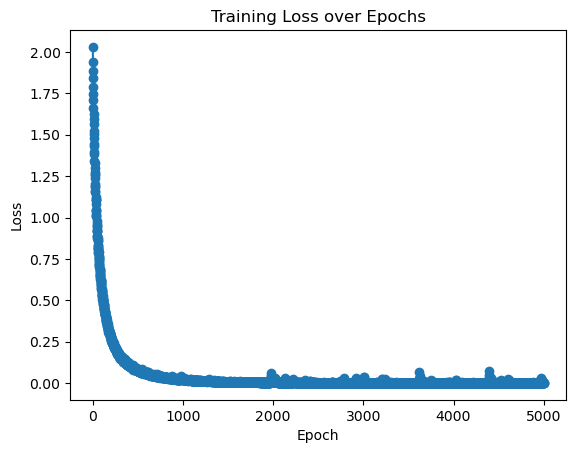

Final training loss: 0.0004529716230504084
Training fold 2/5 with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


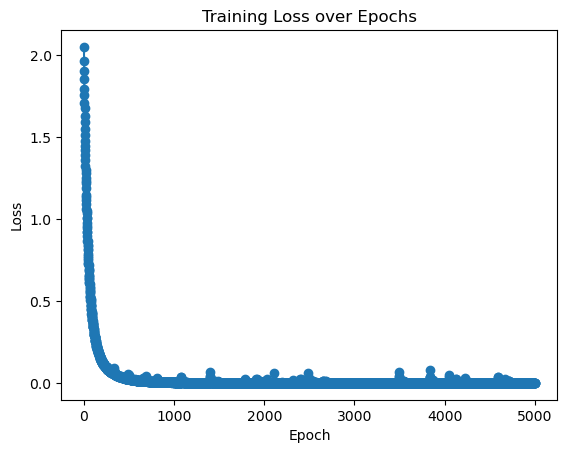

Final training loss: 0.0002270860721565489
Training fold 3/5 with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


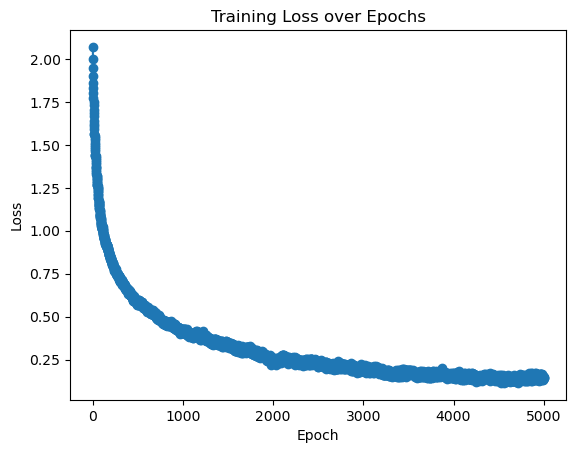

Final training loss: 0.141079969805816
Training fold 4/5 with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


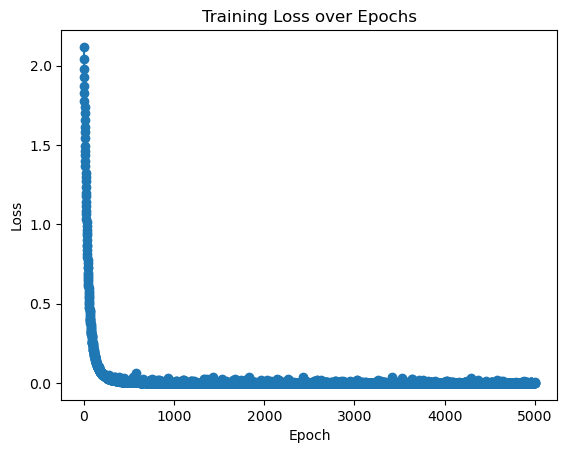

Final training loss: 0.001483569411684797
Training fold 5/5 with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


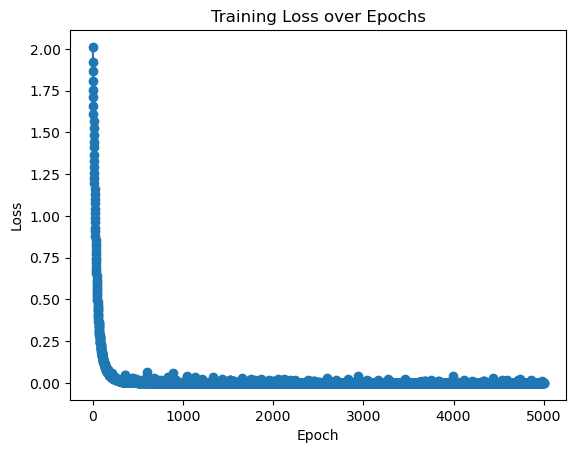

Final training loss: 0.0006226889237833661
[TorchWrapper] Using device: mps


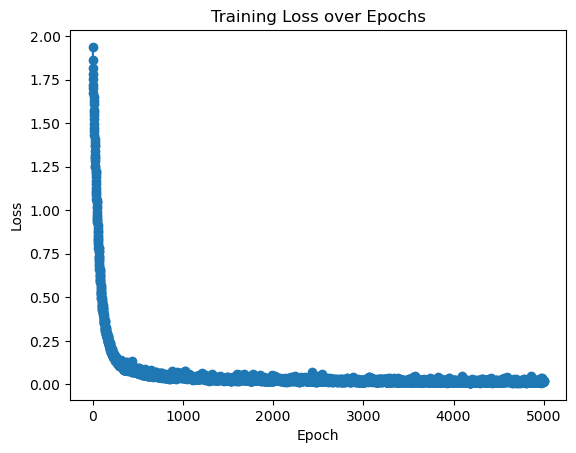

Final training loss: 0.020338898571843525
{'home_goals_train_accuracy': 0.9935672514619883, 'home_goals_train_precision': 0.997074615236324, 'home_goals_valid_accuracy': 0.2672514619883041, 'home_goals_valid_precision': 0.1398934836216465, 'home_goals_test_accuracy': 0.20614035087719298, 'home_goals_test_precision': 0.1324116553736119, 'home_goals_train_lte_0_accuracy': 0.9976608187134502, 'home_goals_train_lte_0_accuracy_std': 0.004678362573099415, 'home_goals_train_lte_0_precision': 0.9969348659003832, 'home_goals_train_lte_0_precision_std': 0.006130268199233724, 'home_goals_train_gt_0_accuracy': 0.9976608187134502, 'home_goals_train_gt_0_accuracy_std': 0.004678362573099415, 'home_goals_train_gt_0_precision': 0.9979084967320262, 'home_goals_train_gt_0_precision_std': 0.004183006535947697, 'home_goals_train_gt_1_accuracy': 0.9949317738791423, 'home_goals_train_gt_1_accuracy_std': 0.010136452241715421, 'home_goals_train_gt_1_precision': 0.9989949748743718, 'home_goals_train_gt_1_precis

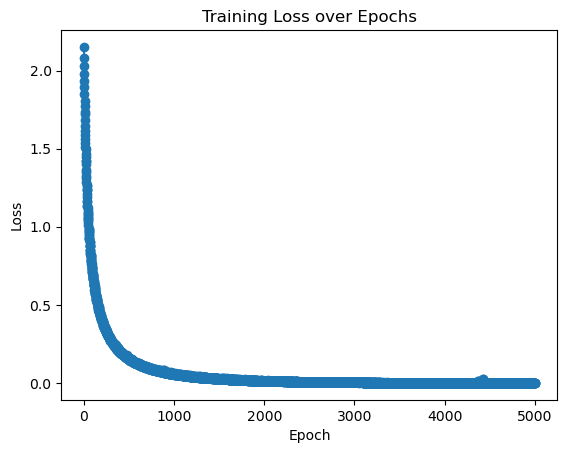

Final training loss: 0.0004673220493969622
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


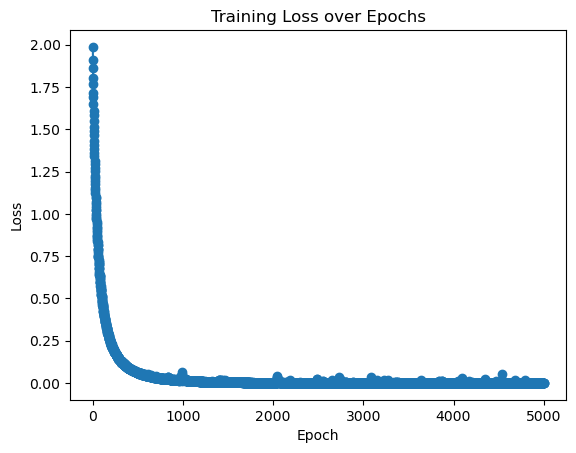

Final training loss: 0.0002452322713859183
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


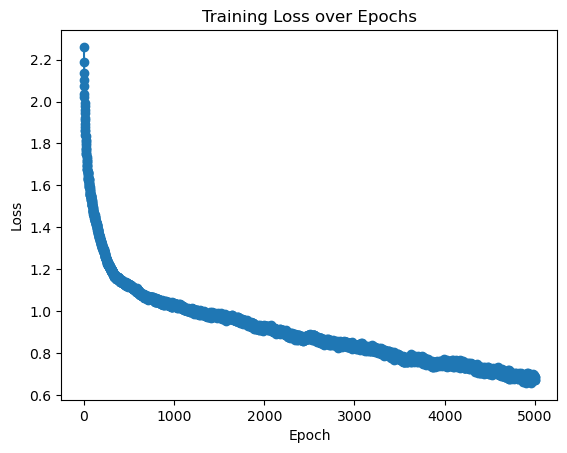

Final training loss: 0.6853543185351187
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


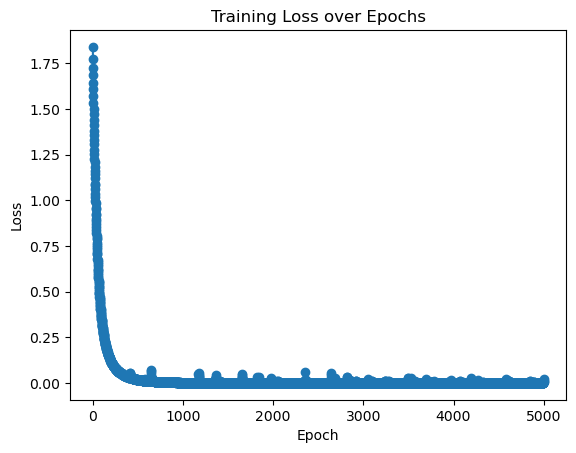

Final training loss: 0.013201563744342814
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


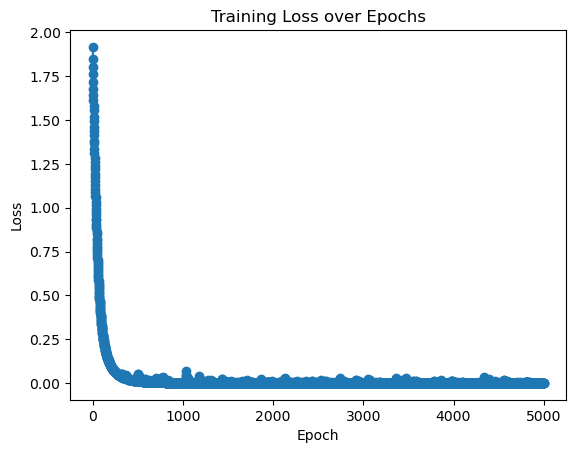

Final training loss: 0.0001835682885163077
[TorchWrapper] Using device: mps


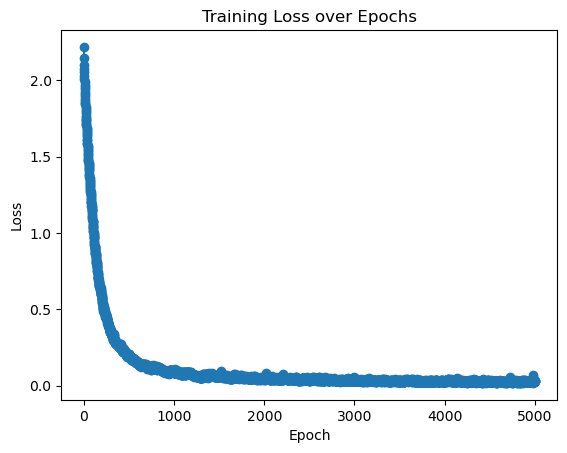

Final training loss: 0.03066475506414447
{'home_goals_train_accuracy': 0.9553606237816764, 'home_goals_train_precision': 0.9315700327257815, 'home_goals_valid_accuracy': 0.27076023391812865, 'home_goals_valid_precision': 0.15486115958046492, 'home_goals_test_accuracy': 0.21929824561403508, 'home_goals_test_precision': 0.1337137862137862, 'home_goals_train_lte_0_accuracy': 0.9749512670565302, 'home_goals_train_lte_0_accuracy_std': 0.04936971888741278, 'home_goals_train_lte_0_precision': 0.9409527225524357, 'home_goals_train_lte_0_precision_std': 0.1153138490903507, 'home_goals_train_gt_0_accuracy': 0.9749512670565302, 'home_goals_train_gt_0_accuracy_std': 0.04936971888741278, 'home_goals_train_gt_0_precision': 0.9908309455587393, 'home_goals_train_gt_0_precision_std': 0.018338108882521496, 'home_goals_train_gt_1_accuracy': 0.9735867446393762, 'home_goals_train_gt_1_accuracy_std': 0.052098593628639056, 'home_goals_train_gt_1_precision': 0.9831395348837209, 'home_goals_train_gt_1_precisio

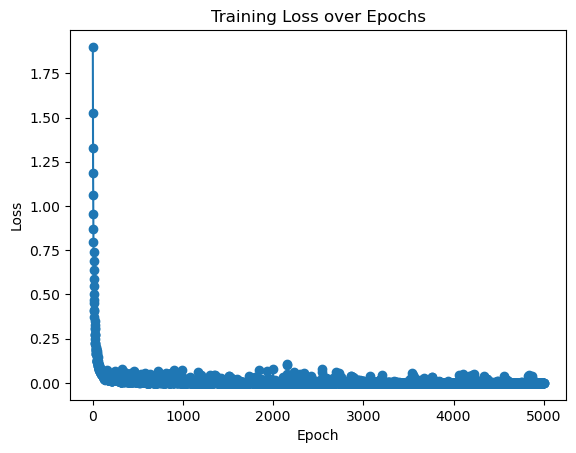

Final training loss: 0.00026334308333591453
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


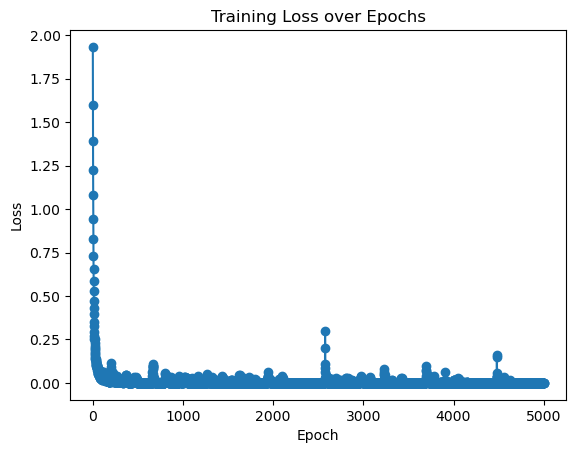

Final training loss: 0.00023115222192197842
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


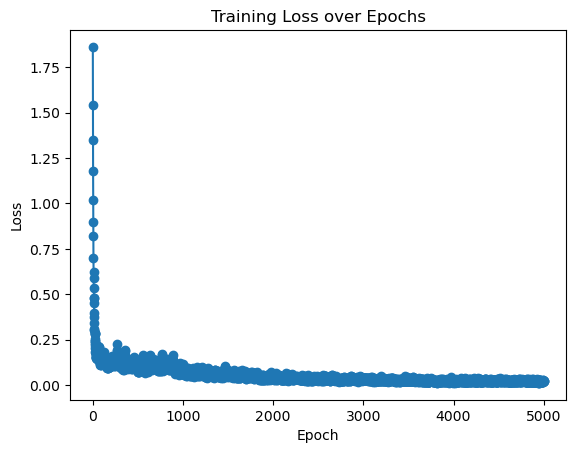

Final training loss: 0.02040668296651301
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


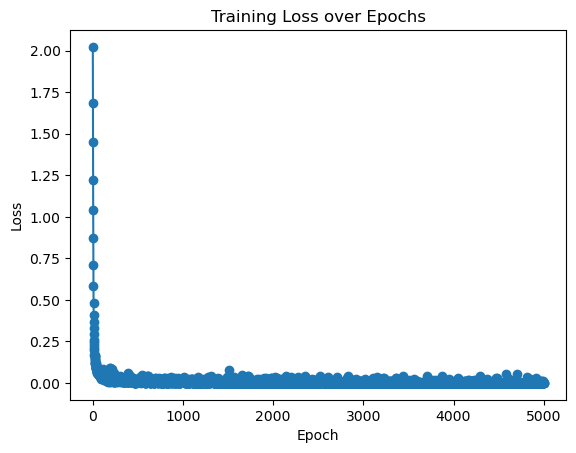

Final training loss: 0.0007518093269835743
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


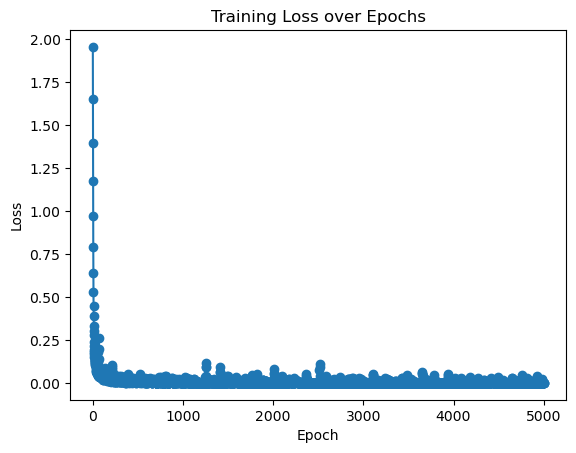

Final training loss: 0.0005621916266588484
[TorchWrapper] Using device: mps


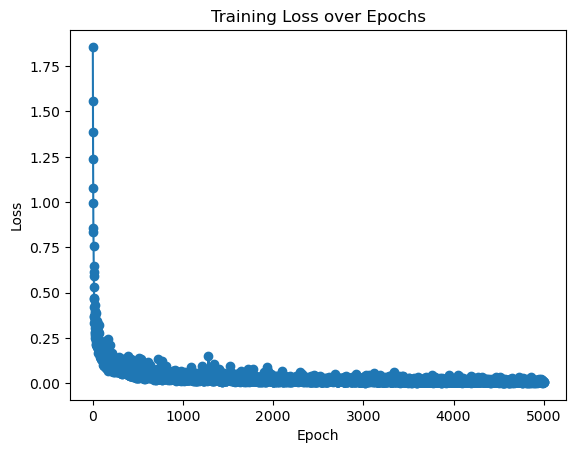

Final training loss: 0.008730605418919122
{'home_goals_train_accuracy': 1.0, 'home_goals_train_precision': 1.0, 'home_goals_valid_accuracy': 0.2807017543859649, 'home_goals_valid_precision': 0.1620123610477476, 'home_goals_test_accuracy': 0.2543859649122807, 'home_goals_test_precision': 0.14907477211635384, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 1.0, 'home_goals_train_gt_0_accuracy_std': 0.0, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 1.0, 'home_goals_train_gt_1_accuracy_std': 0.0, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 1.0, 'home_goals_train_gt_2_accuracy_std': 0.0, 'home_goals_train_gt_2_precision': 1.0, 'home_goals_train_gt_2_precision_std': 0.0, 'home_goals_train_gt_3_

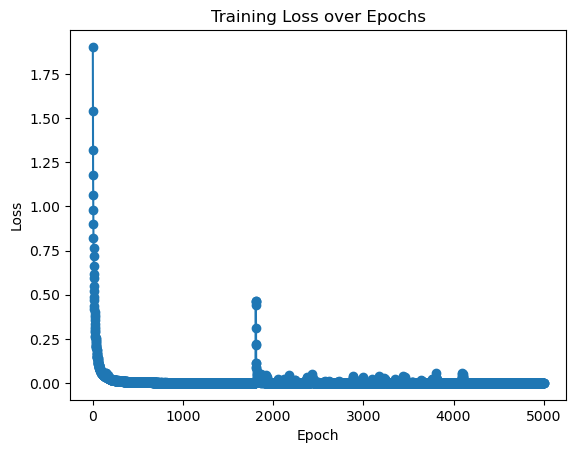

Final training loss: 0.0002623131399639278
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


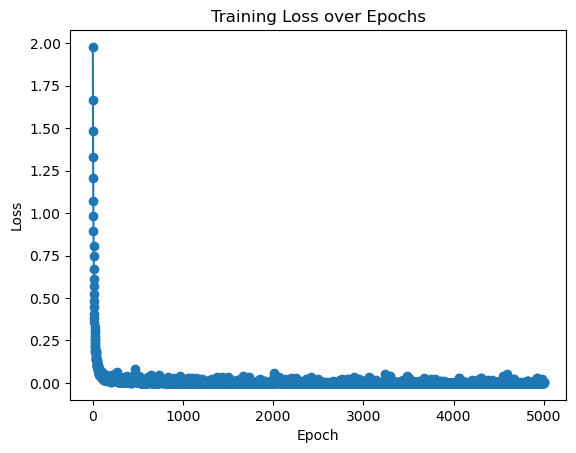

Final training loss: 0.0022745050533473144
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


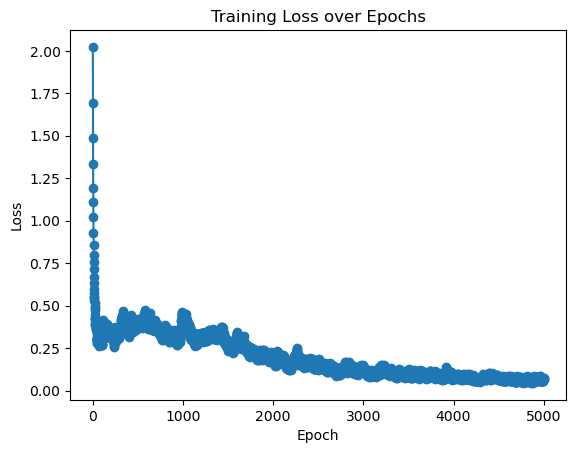

Final training loss: 0.06652417471069574
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


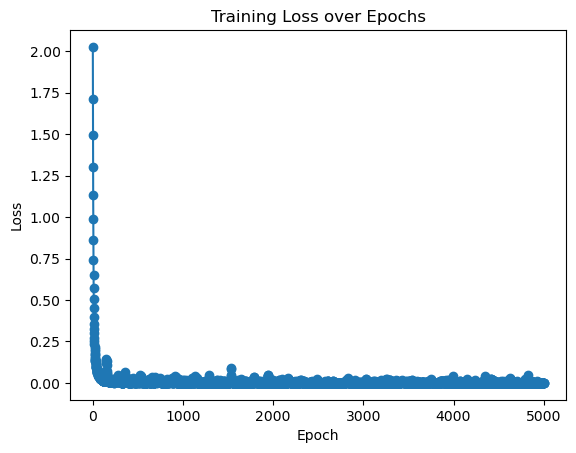

Final training loss: 0.0006776638631981237
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


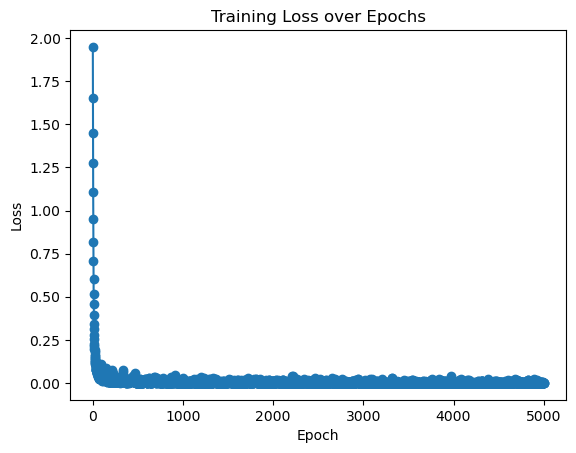

Final training loss: 0.0005603446019949576
[TorchWrapper] Using device: mps


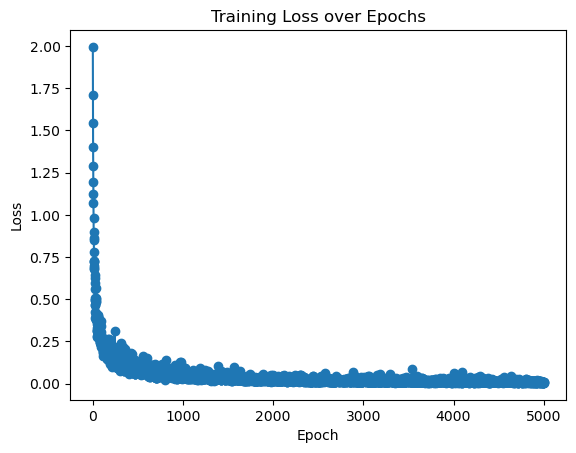

Final training loss: 0.009119366693217851
{'home_goals_train_accuracy': 0.9980506822612085, 'home_goals_train_precision': 0.9981405700828055, 'home_goals_valid_accuracy': 0.2654970760233918, 'home_goals_valid_precision': 0.13947279194050566, 'home_goals_test_accuracy': 0.2719298245614035, 'home_goals_test_precision': 0.17426043957053503, 'home_goals_train_lte_0_accuracy': 0.9990253411306043, 'home_goals_train_lte_0_accuracy_std': 0.001949317738791434, 'home_goals_train_lte_0_precision': 0.9992366412213741, 'home_goals_train_lte_0_precision_std': 0.0015267175572518886, 'home_goals_train_gt_0_accuracy': 0.9990253411306043, 'home_goals_train_gt_0_accuracy_std': 0.001949317738791434, 'home_goals_train_gt_0_precision': 0.9989528795811518, 'home_goals_train_gt_0_precision_std': 0.0020942408376963153, 'home_goals_train_gt_1_accuracy': 0.9992202729044835, 'home_goals_train_gt_1_accuracy_std': 0.0015594541910331384, 'home_goals_train_gt_1_precision': 0.9995215311004785, 'home_goals_train_gt_1_p

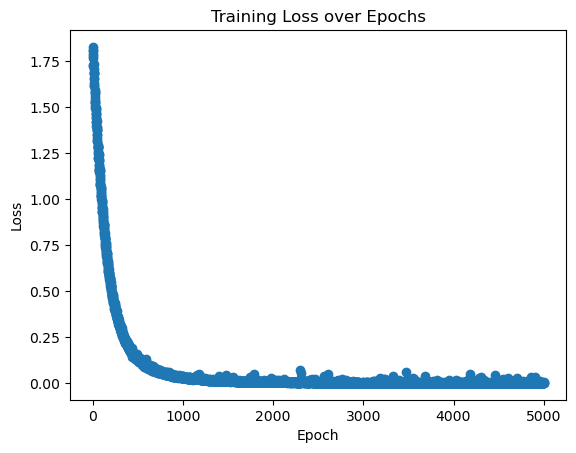

Final training loss: 0.0009002864118447604
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


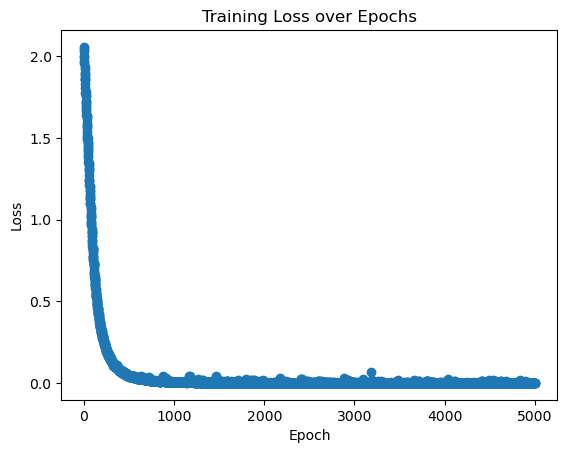

Final training loss: 0.0005302088531224351
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


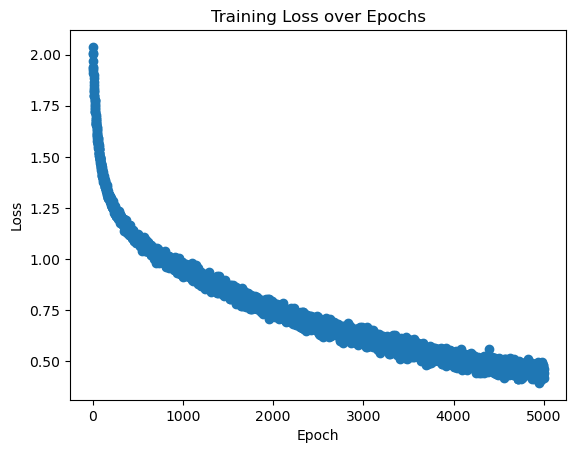

Final training loss: 0.41948020481459114
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


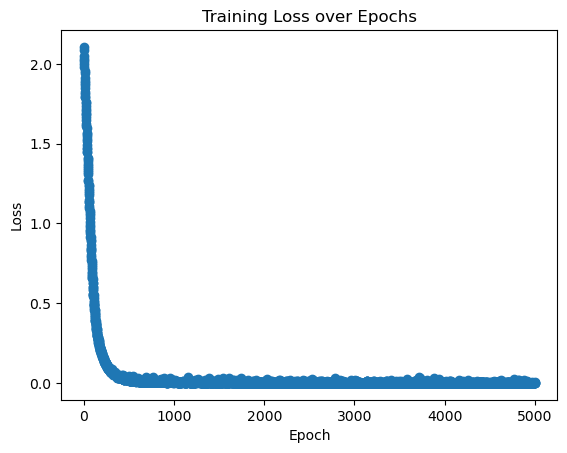

Final training loss: 0.0010851951617589601
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


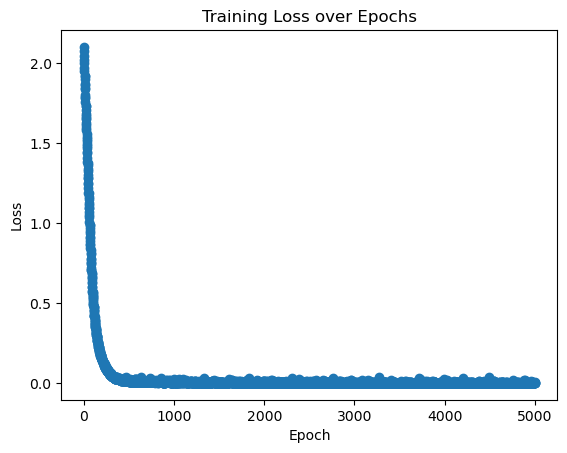

Final training loss: 0.0005977730930351232
[TorchWrapper] Using device: mps


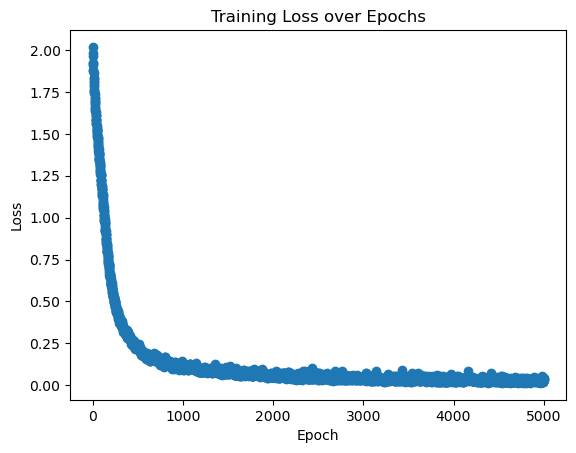

Final training loss: 0.029369083993848535
{'home_goals_train_accuracy': 0.9914230019493179, 'home_goals_train_precision': 0.9639618612920515, 'home_goals_valid_accuracy': 0.26842105263157895, 'home_goals_valid_precision': 0.16517118202201386, 'home_goals_test_accuracy': 0.3026315789473684, 'home_goals_test_precision': 0.20645876174636854, 'home_goals_train_lte_0_accuracy': 0.9962962962962962, 'home_goals_train_lte_0_accuracy_std': 0.007407407407407395, 'home_goals_train_lte_0_precision': 0.9976190476190476, 'home_goals_train_lte_0_precision_std': 0.004761904761904744, 'home_goals_train_gt_0_accuracy': 0.9962962962962962, 'home_goals_train_gt_0_accuracy_std': 0.007407407407407395, 'home_goals_train_gt_0_precision': 0.9958656330749355, 'home_goals_train_gt_0_precision_std': 0.008268733850129184, 'home_goals_train_gt_1_accuracy': 0.9955165692007798, 'home_goals_train_gt_1_accuracy_std': 0.008966861598440535, 'home_goals_train_gt_1_precision': 0.9934117647058823, 'home_goals_train_gt_1_pre

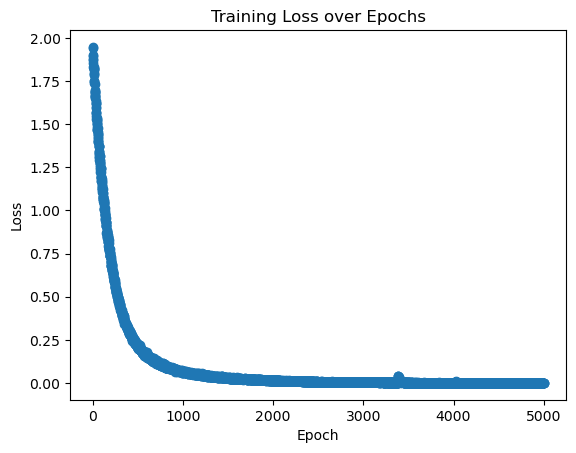

Final training loss: 0.0004977112474622565
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


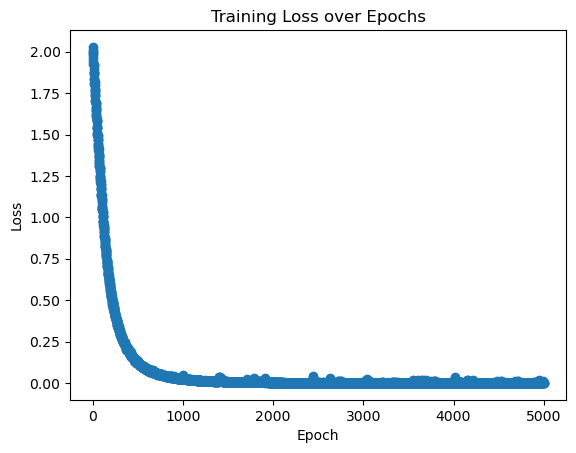

Final training loss: 0.0004058248068652611
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


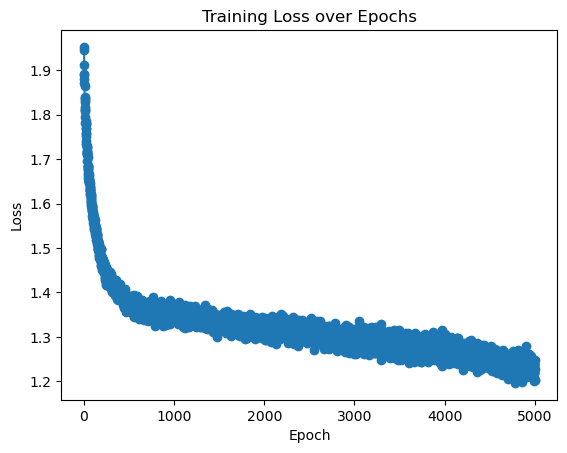

Final training loss: 1.202367700796146
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


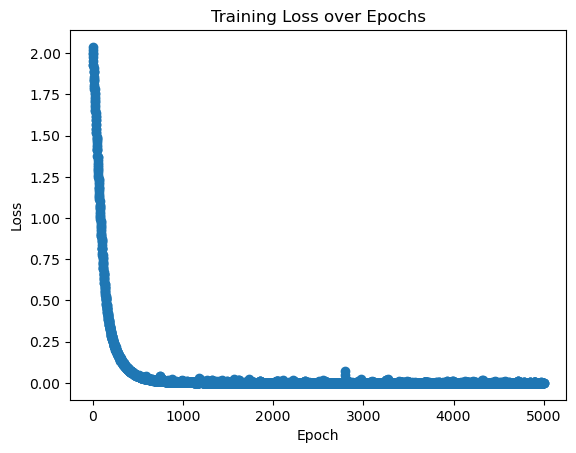

Final training loss: 0.00038847945901505346
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


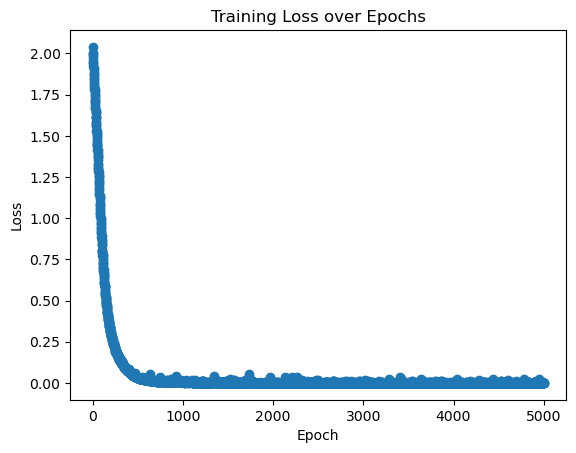

Final training loss: 0.0006071904503293772
[TorchWrapper] Using device: mps


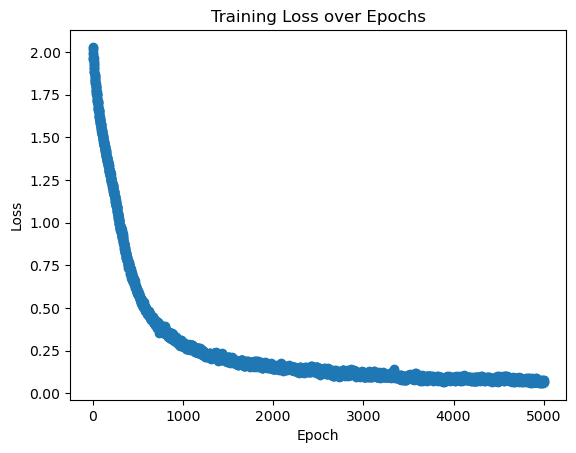

Final training loss: 0.06655920873492317
{'home_goals_train_accuracy': 0.9263157894736842, 'home_goals_train_precision': 0.9061987577728916, 'home_goals_valid_accuracy': 0.2637426900584795, 'home_goals_valid_precision': 0.1651549129562883, 'home_goals_test_accuracy': 0.25, 'home_goals_test_precision': 0.14078112663018322, 'home_goals_train_lte_0_accuracy': 0.9729044834307992, 'home_goals_train_lte_0_accuracy_std': 0.05419103313840154, 'home_goals_train_lte_0_precision': 0.9707865168539325, 'home_goals_train_lte_0_precision_std': 0.05842696629213484, 'home_goals_train_gt_0_accuracy': 0.9729044834307992, 'home_goals_train_gt_0_accuracy_std': 0.05419103313840154, 'home_goals_train_gt_0_precision': 0.9733490566037736, 'home_goals_train_gt_0_precision_std': 0.053301886792452846, 'home_goals_train_gt_1_accuracy': 0.9549707602339181, 'home_goals_train_gt_1_accuracy_std': 0.09005847953216373, 'home_goals_train_gt_1_precision': 0.96, 'home_goals_train_gt_1_precision_std': 0.07999999999999999, '

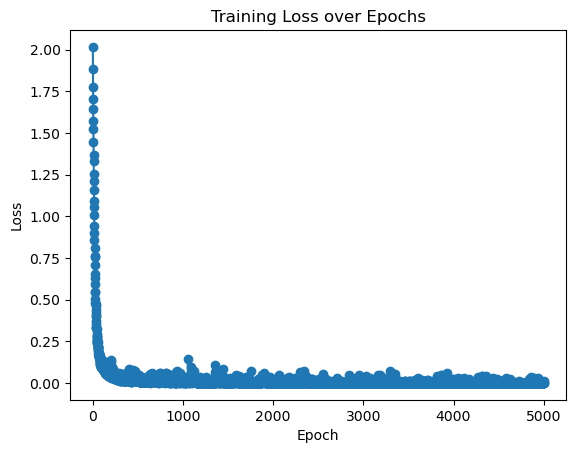

Final training loss: 0.0004972560734253878
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


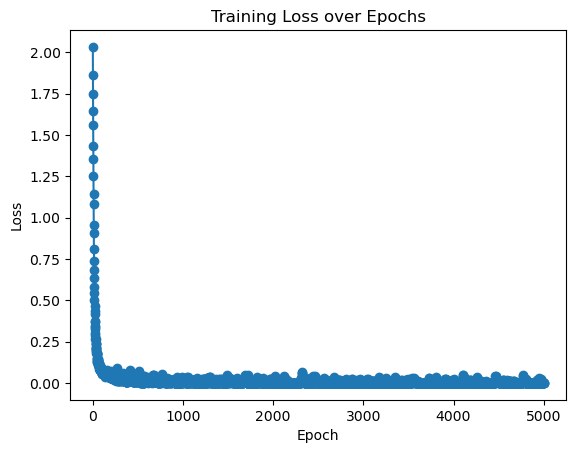

Final training loss: 0.0006519088539300345
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


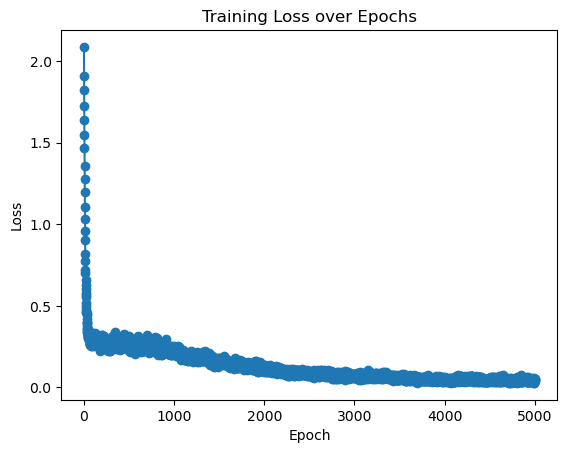

Final training loss: 0.05322580013358802
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


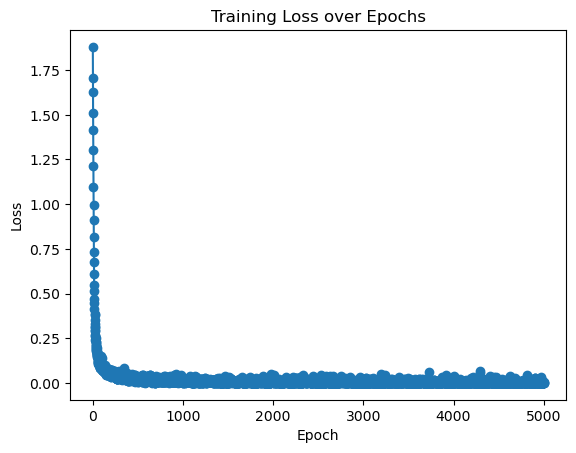

Final training loss: 0.0051088887260006795
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


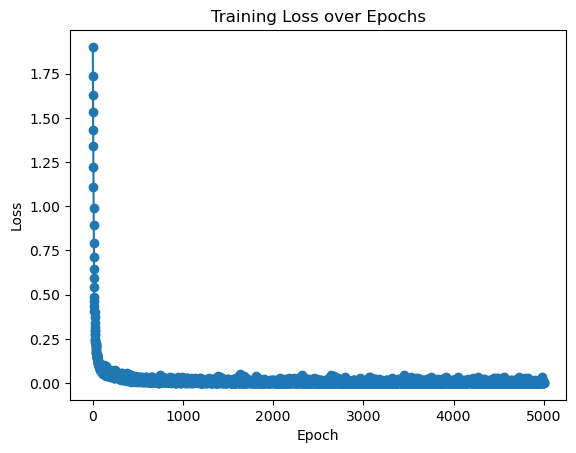

Final training loss: 0.0014151480236793297
[TorchWrapper] Using device: mps


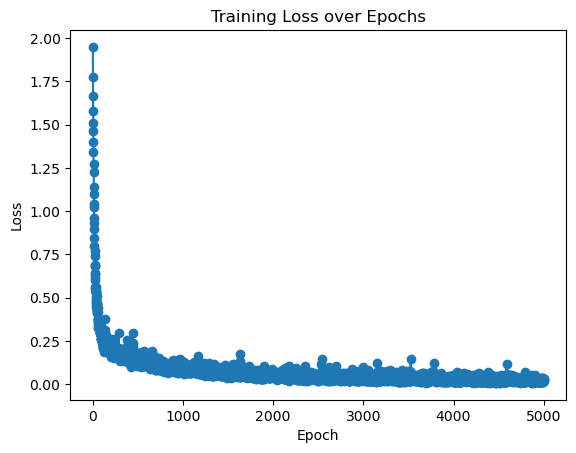

Final training loss: 0.02848295244382836
{'home_goals_train_accuracy': 1.0, 'home_goals_train_precision': 1.0, 'home_goals_valid_accuracy': 0.2760233918128655, 'home_goals_valid_precision': 0.18750209529364104, 'home_goals_test_accuracy': 0.2631578947368421, 'home_goals_test_precision': 0.17304023469791666, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 1.0, 'home_goals_train_gt_0_accuracy_std': 0.0, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 1.0, 'home_goals_train_gt_1_accuracy_std': 0.0, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 1.0, 'home_goals_train_gt_2_accuracy_std': 0.0, 'home_goals_train_gt_2_precision': 1.0, 'home_goals_train_gt_2_precision_std': 0.0, 'home_goals_train_gt_3_

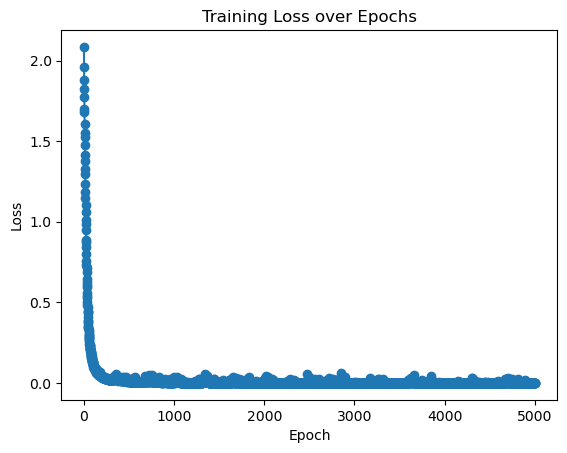

Final training loss: 0.00026361027845502857
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


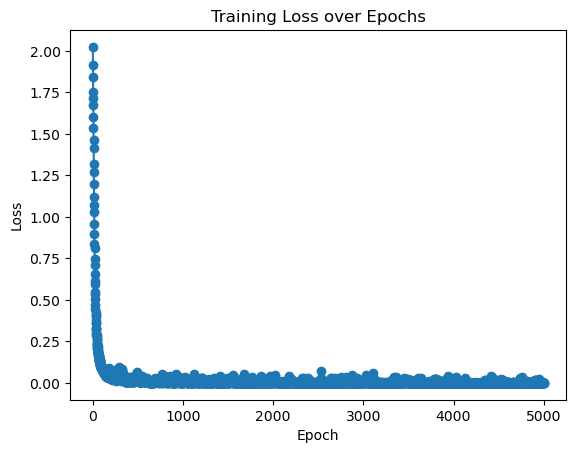

Final training loss: 0.0004497111042449523
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


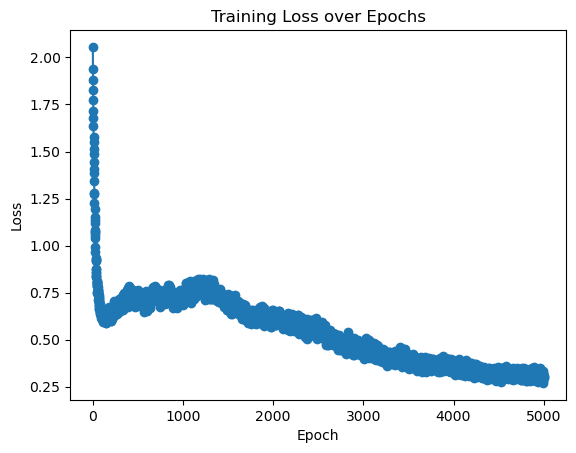

Final training loss: 0.29695994829573824
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


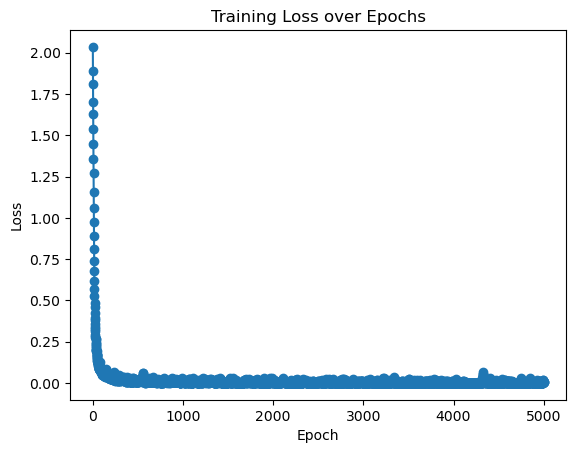

Final training loss: 0.0033258125056616133
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


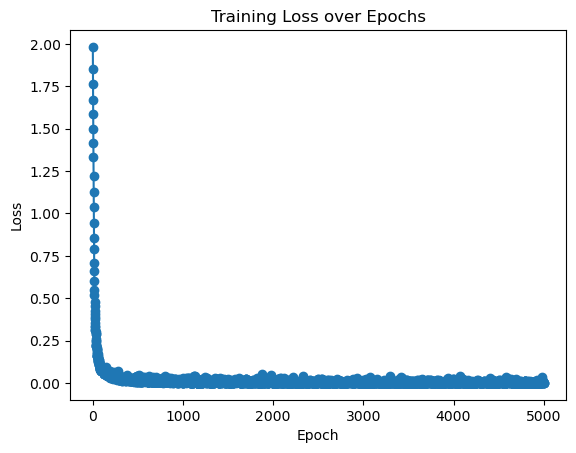

Final training loss: 0.0024497463314267073
[TorchWrapper] Using device: mps


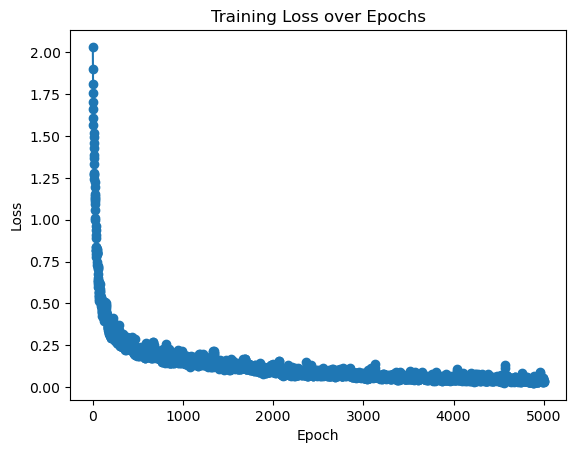

Final training loss: 0.03928094875742817
{'home_goals_train_accuracy': 0.9929824561403509, 'home_goals_train_precision': 0.9962561676682086, 'home_goals_valid_accuracy': 0.26432748538011697, 'home_goals_valid_precision': 0.1472947092812209, 'home_goals_test_accuracy': 0.21052631578947367, 'home_goals_test_precision': 0.13339830916102102, 'home_goals_train_lte_0_accuracy': 0.9966861598440545, 'home_goals_train_lte_0_accuracy_std': 0.006627680311890849, 'home_goals_train_lte_0_precision': 0.9925373134328359, 'home_goals_train_lte_0_precision_std': 0.014925373134328356, 'home_goals_train_gt_0_accuracy': 0.9966861598440545, 'home_goals_train_gt_0_accuracy_std': 0.006627680311890849, 'home_goals_train_gt_0_precision': 0.9981530343007915, 'home_goals_train_gt_0_precision_std': 0.003693931398416872, 'home_goals_train_gt_1_accuracy': 0.9953216374269006, 'home_goals_train_gt_1_accuracy_std': 0.00935672514619883, 'home_goals_train_gt_1_precision': 0.9985074626865671, 'home_goals_train_gt_1_preci

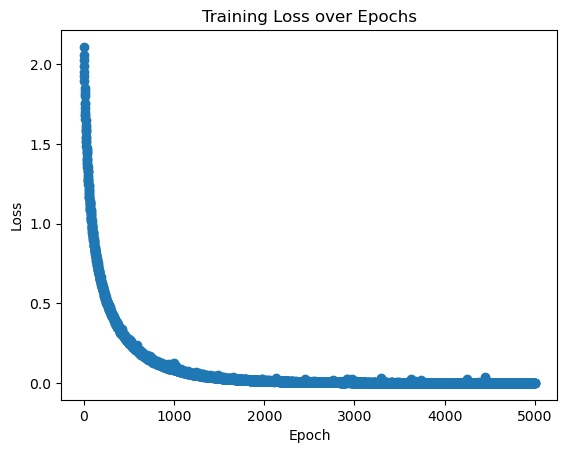

Final training loss: 0.0006170666392631175
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


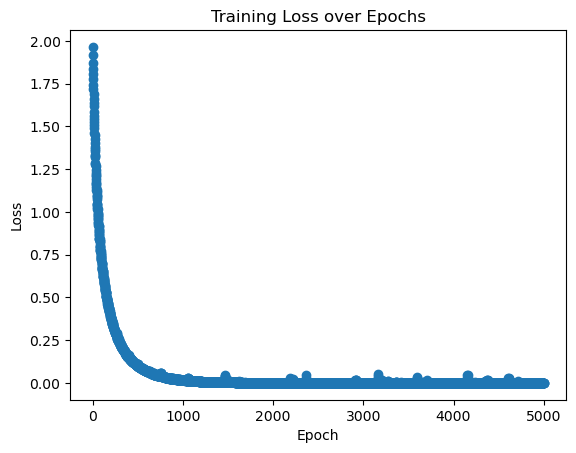

Final training loss: 0.00029366580484848883
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


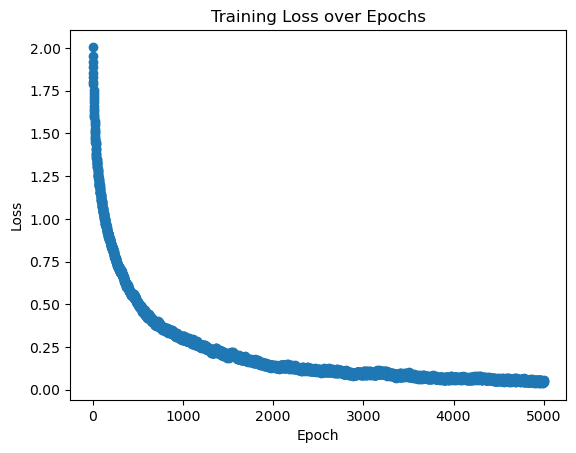

Final training loss: 0.05519650774857222
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


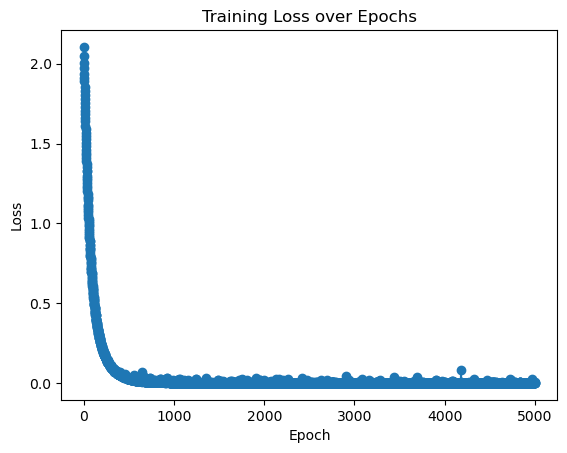

Final training loss: 0.003091044616422545
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


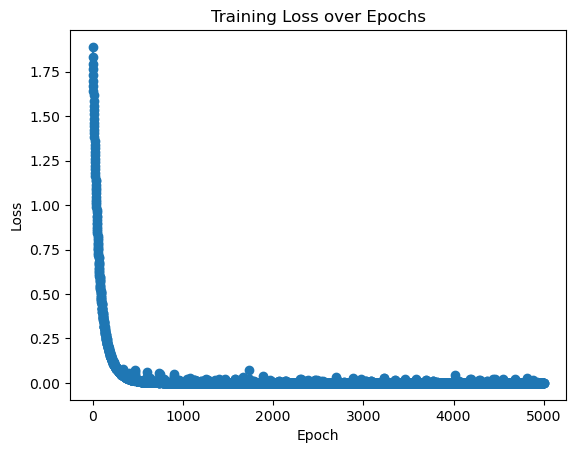

Final training loss: 0.0002904940648440119
[TorchWrapper] Using device: mps


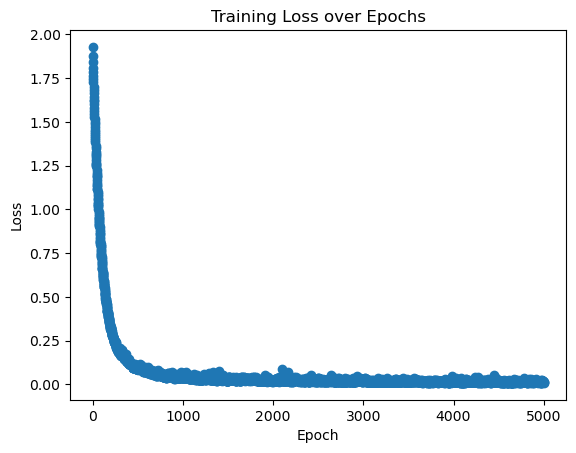

Final training loss: 0.010809052597593379
{'home_goals_train_accuracy': 1.0, 'home_goals_train_precision': 1.0, 'home_goals_valid_accuracy': 0.256140350877193, 'home_goals_valid_precision': 0.1566579473343613, 'home_goals_test_accuracy': 0.2412280701754386, 'home_goals_test_precision': 0.1401180888094585, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 1.0, 'home_goals_train_gt_0_accuracy_std': 0.0, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 1.0, 'home_goals_train_gt_1_accuracy_std': 0.0, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 1.0, 'home_goals_train_gt_2_accuracy_std': 0.0, 'home_goals_train_gt_2_precision': 1.0, 'home_goals_train_gt_2_precision_std': 0.0, 'home_goals_train_gt_3_ac

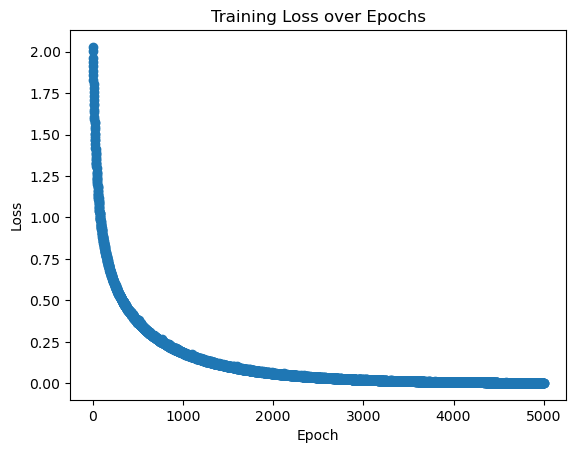

Final training loss: 0.0034795937820049057
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


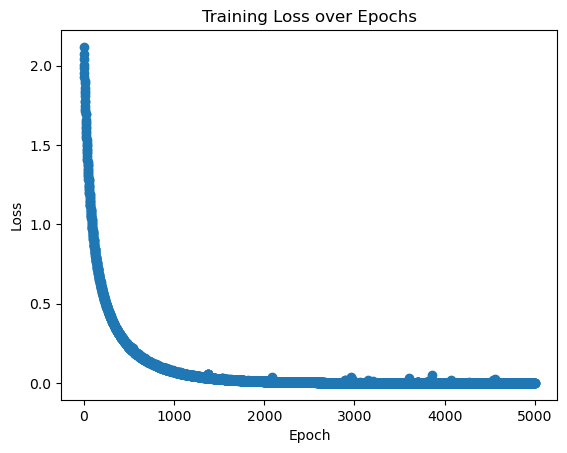

Final training loss: 0.000364129316832391
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


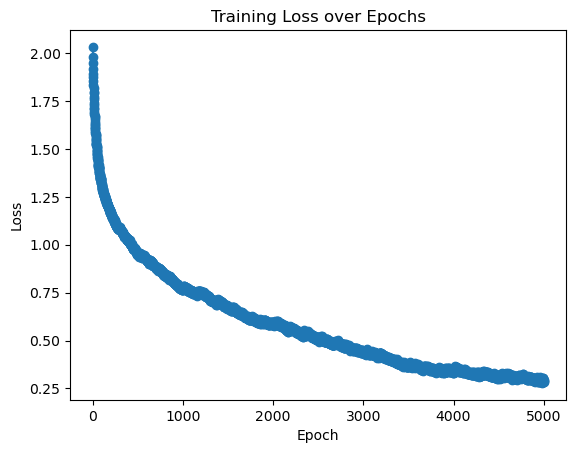

Final training loss: 0.28730857209620186
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


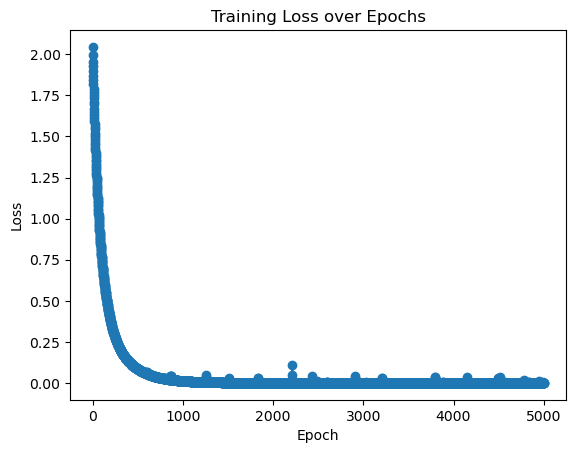

Final training loss: 0.0013427827243450811
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


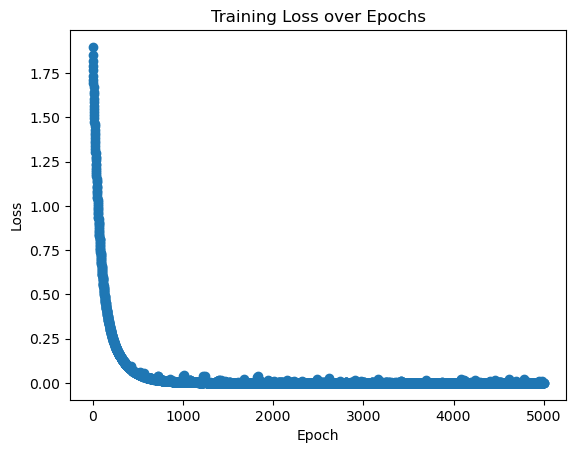

Final training loss: 0.00033052880010616623
[TorchWrapper] Using device: mps


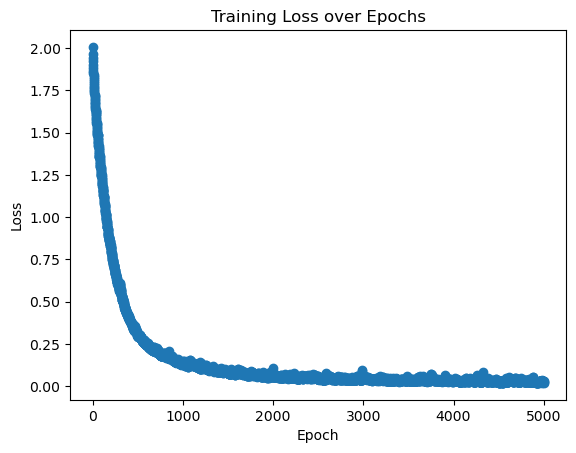

Final training loss: 0.020769999041194805
{'home_goals_train_accuracy': 0.9895224171539961, 'home_goals_train_precision': 0.9608179241256231, 'home_goals_valid_accuracy': 0.2637426900584795, 'home_goals_valid_precision': 0.1572669692257239, 'home_goals_test_accuracy': 0.23684210526315788, 'home_goals_test_precision': 0.1336143152913339, 'home_goals_train_lte_0_accuracy': 0.997270955165692, 'home_goals_train_lte_0_accuracy_std': 0.0054580896686160065, 'home_goals_train_lte_0_precision': 0.991941391941392, 'home_goals_train_lte_0_precision_std': 0.016117216117216105, 'home_goals_train_gt_0_accuracy': 0.997270955165692, 'home_goals_train_gt_0_accuracy_std': 0.0054580896686160065, 'home_goals_train_gt_0_precision': 0.999203187250996, 'home_goals_train_gt_0_precision_std': 0.0015936254980079667, 'home_goals_train_gt_1_accuracy': 0.9927875243664717, 'home_goals_train_gt_1_accuracy_std': 0.01442495126705654, 'home_goals_train_gt_1_precision': 0.9984575835475578, 'home_goals_train_gt_1_precisi

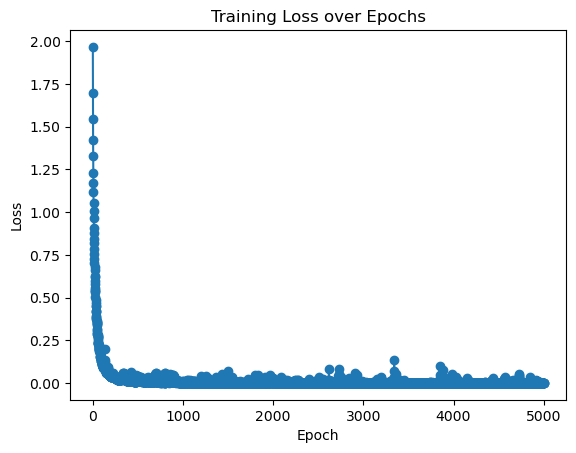

Final training loss: 0.00017629239317751354
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


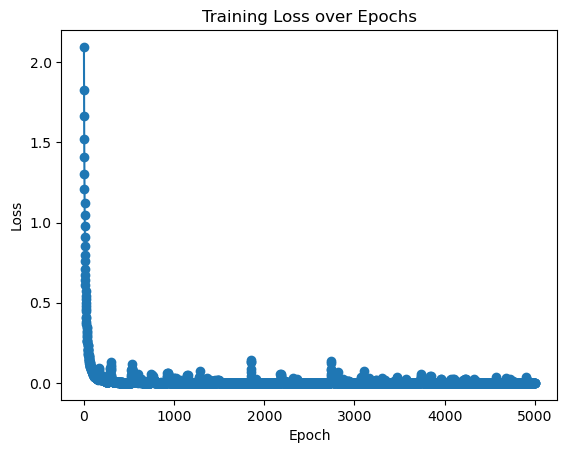

Final training loss: 0.00025586752467434743
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


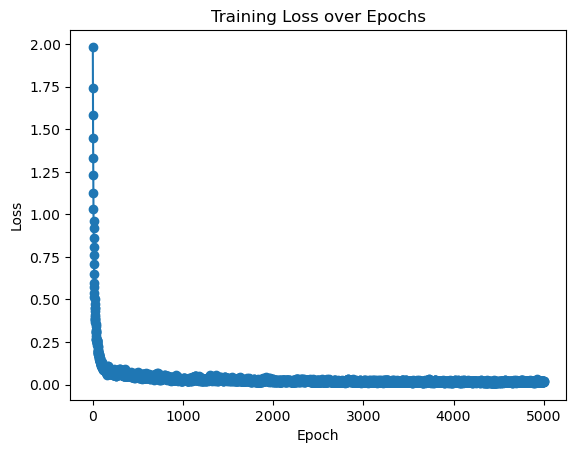

Final training loss: 0.018826969563380088
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


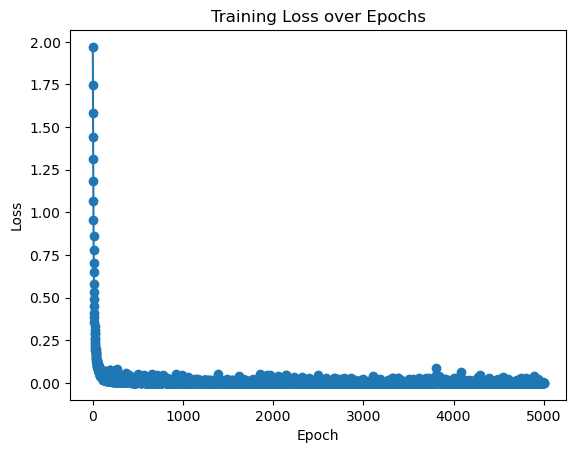

Final training loss: 0.00046094216485317163
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


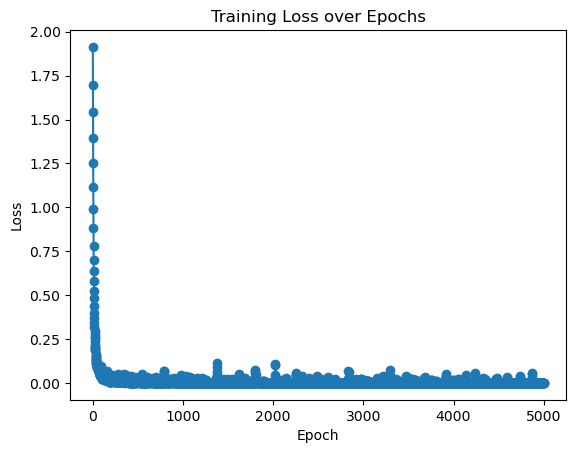

Final training loss: 0.0002754916493135521
[TorchWrapper] Using device: mps


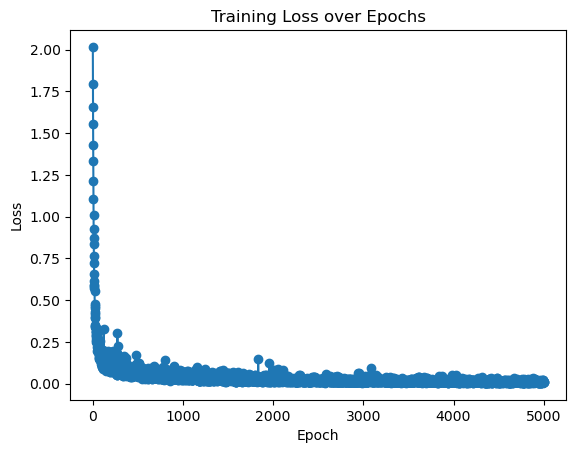

Final training loss: 0.00936137667728214
{'home_goals_train_accuracy': 1.0, 'home_goals_train_precision': 1.0, 'home_goals_valid_accuracy': 0.2818713450292398, 'home_goals_valid_precision': 0.1468343619273621, 'home_goals_test_accuracy': 0.2675438596491228, 'home_goals_test_precision': 0.17516480276321053, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 1.0, 'home_goals_train_gt_0_accuracy_std': 0.0, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 1.0, 'home_goals_train_gt_1_accuracy_std': 0.0, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 1.0, 'home_goals_train_gt_2_accuracy_std': 0.0, 'home_goals_train_gt_2_precision': 1.0, 'home_goals_train_gt_2_precision_std': 0.0, 'home_goals_train_gt_3_a

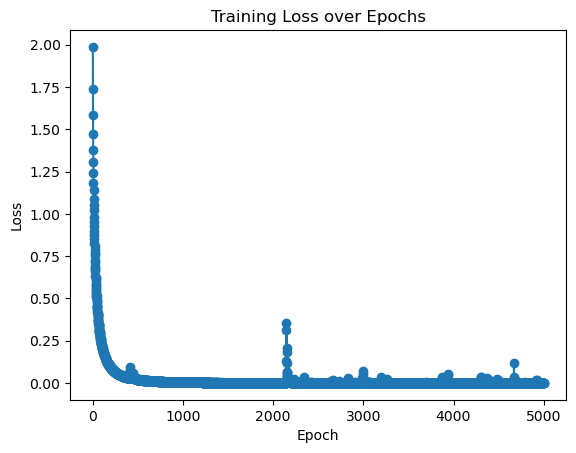

Final training loss: 0.00023944534130574188
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


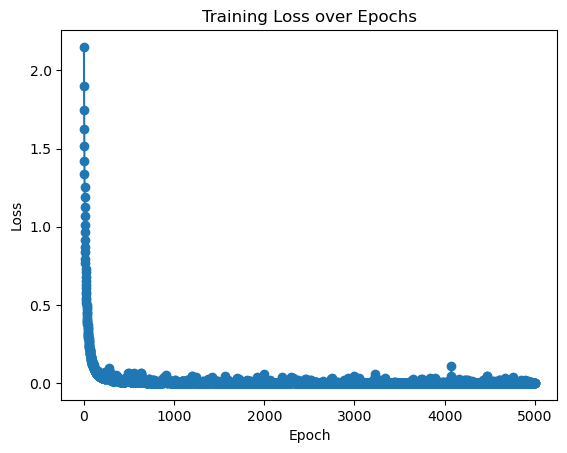

Final training loss: 0.0003173626017789438
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


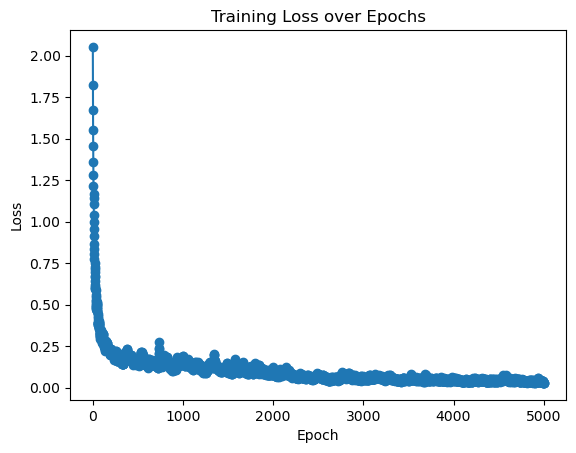

Final training loss: 0.02946482043982017
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


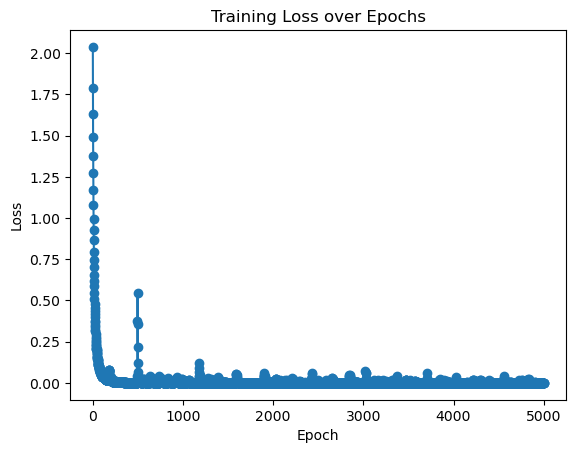

Final training loss: 0.0002151213297674879
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


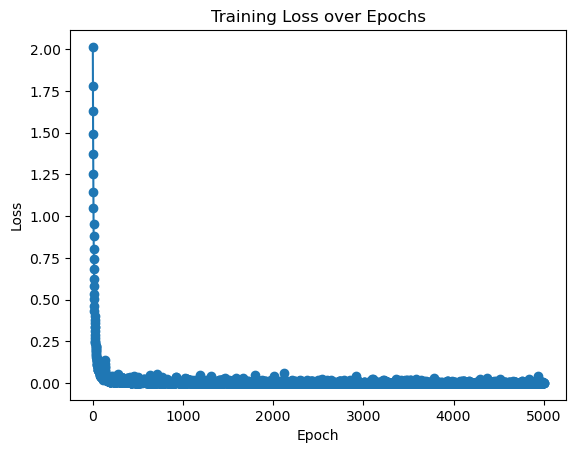

Final training loss: 0.00031477768649483285
[TorchWrapper] Using device: mps


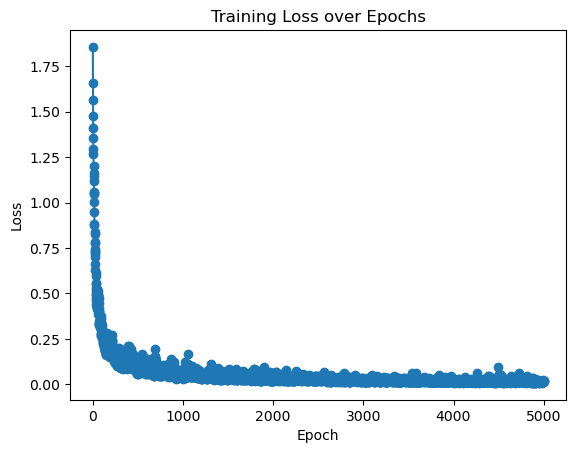

Final training loss: 0.018072819791109706
{'home_goals_train_accuracy': 0.9998050682261208, 'home_goals_train_precision': 0.9999164578111946, 'home_goals_valid_accuracy': 0.27134502923976606, 'home_goals_valid_precision': 0.15089511589087454, 'home_goals_test_accuracy': 0.24561403508771928, 'home_goals_test_precision': 0.13534069768195836, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 1.0, 'home_goals_train_gt_0_accuracy_std': 0.0, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 0.9998050682261208, 'home_goals_train_gt_1_accuracy_std': 0.0003898635477582957, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 0.9998050682261208, 'home_goals_train_gt_2_accuracy_std': 0.0003898635477582957, 'home_go

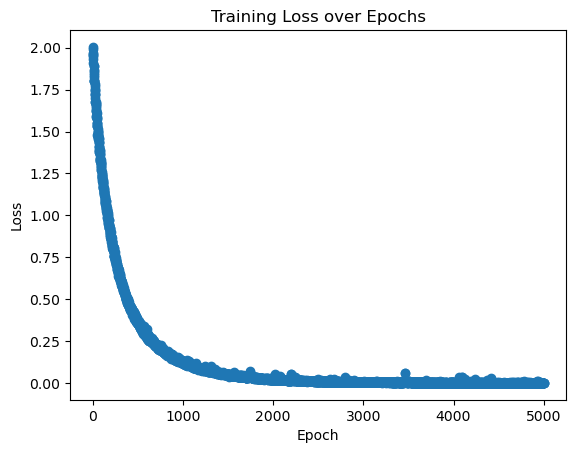

Final training loss: 0.002186425618435207
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


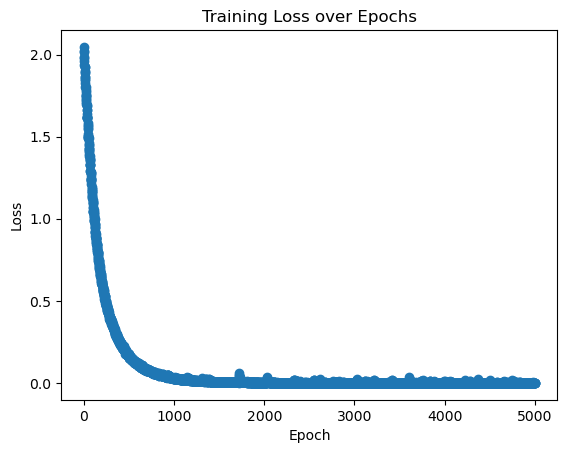

Final training loss: 0.00040512171618869167
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


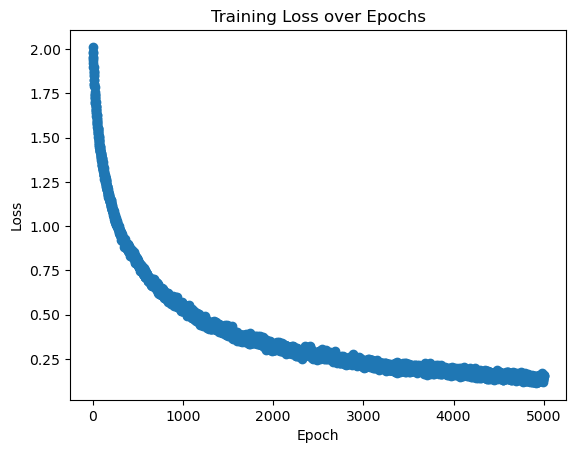

Final training loss: 0.15252387593364158
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


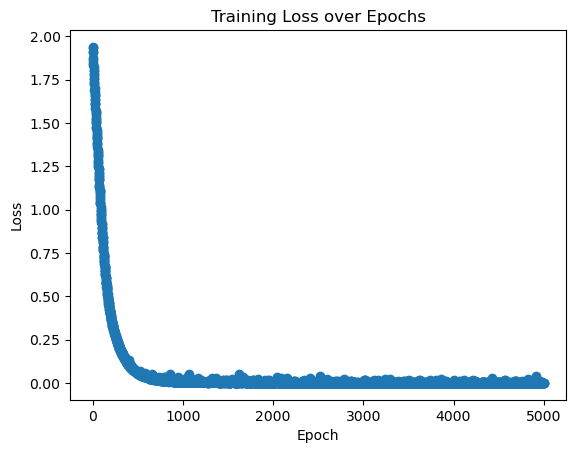

Final training loss: 0.0007456309796577831
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


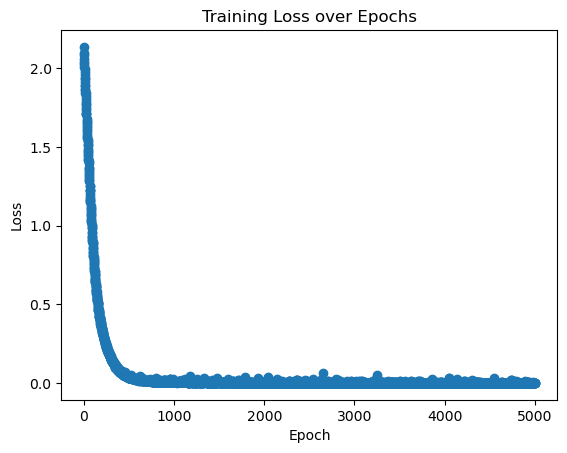

Final training loss: 0.0029837117228474555
[TorchWrapper] Using device: mps


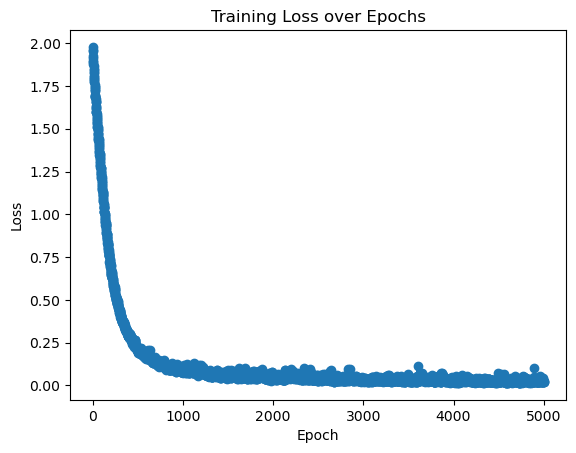

Final training loss: 0.023317736375633967
{'home_goals_train_accuracy': 0.9988304093567251, 'home_goals_train_precision': 0.9993021483730822, 'home_goals_valid_accuracy': 0.27017543859649124, 'home_goals_valid_precision': 0.15300443676514083, 'home_goals_test_accuracy': 0.2631578947368421, 'home_goals_test_precision': 0.17638430807736732, 'home_goals_train_lte_0_accuracy': 0.9992202729044835, 'home_goals_train_lte_0_accuracy_std': 0.0015594541910331384, 'home_goals_train_lte_0_precision': 0.9984905660377358, 'home_goals_train_lte_0_precision_std': 0.0030188679245283013, 'home_goals_train_gt_0_accuracy': 0.9992202729044835, 'home_goals_train_gt_0_accuracy_std': 0.0015594541910331384, 'home_goals_train_gt_0_precision': 0.9994743758212877, 'home_goals_train_gt_0_precision_std': 0.0010512483574244501, 'home_goals_train_gt_1_accuracy': 0.9994152046783625, 'home_goals_train_gt_1_accuracy_std': 0.0011695906432748425, 'home_goals_train_gt_1_precision': 0.9985815602836879, 'home_goals_train_gt_

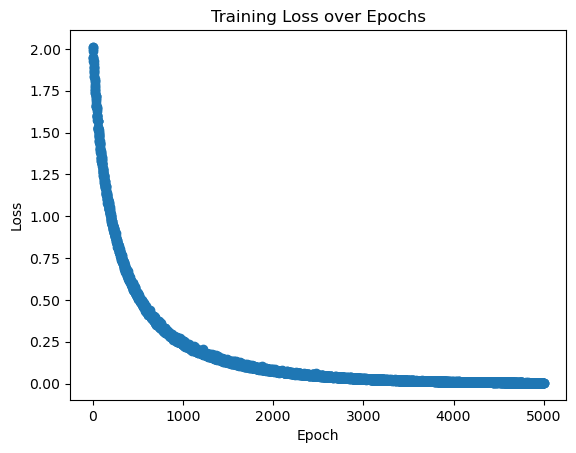

Final training loss: 0.00439763889642574
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


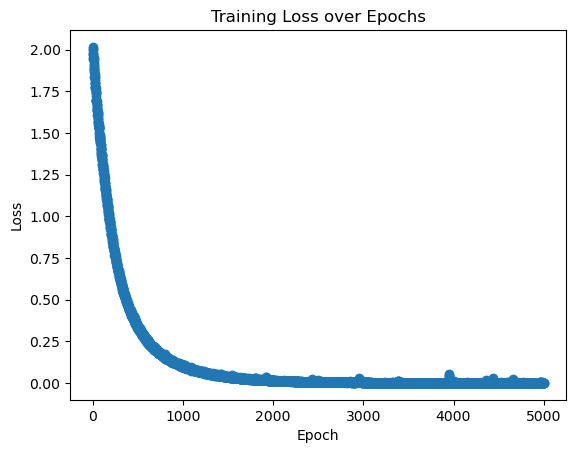

Final training loss: 0.0007805654150025363
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


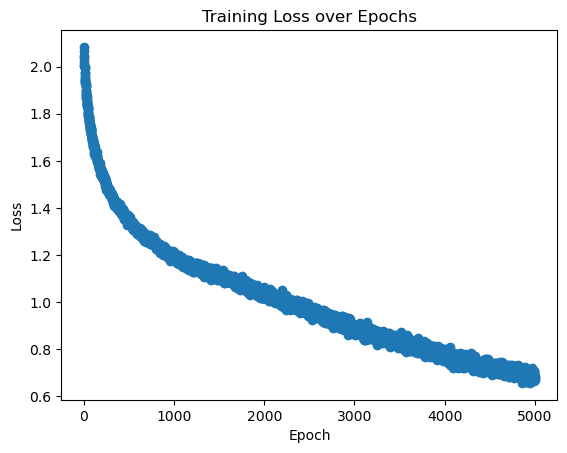

Final training loss: 0.6715267962879605
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


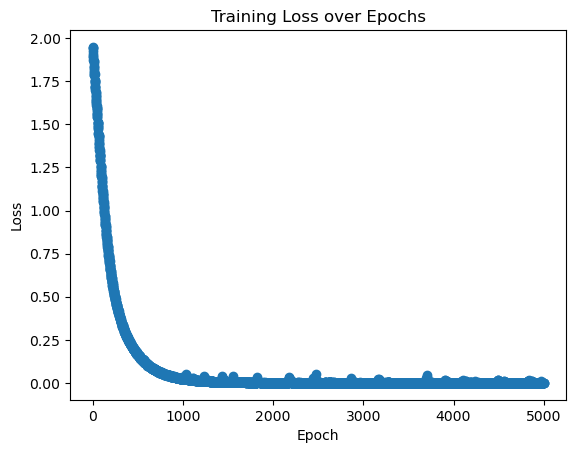

Final training loss: 0.0004554917203257002
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


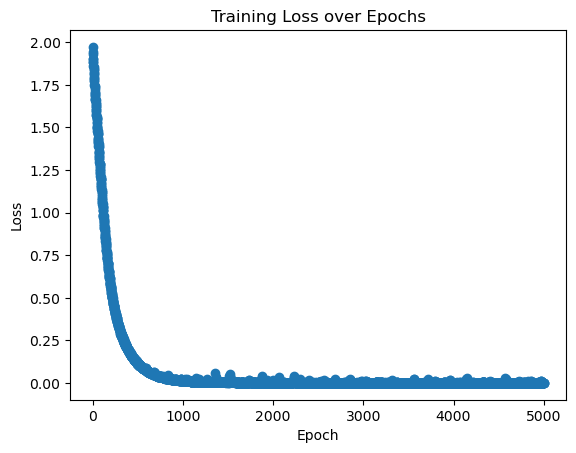

Final training loss: 0.00042262689839525706
[TorchWrapper] Using device: mps


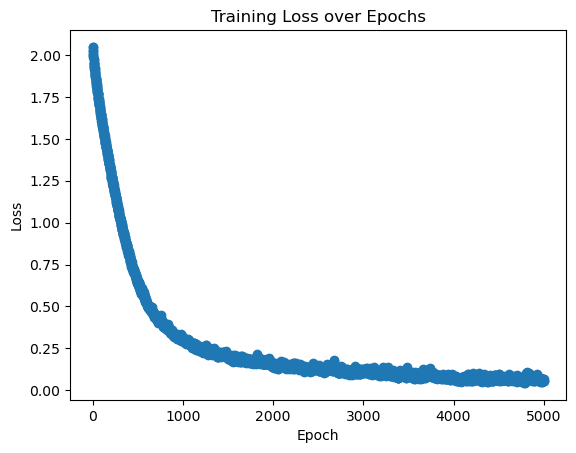

Final training loss: 0.05265949390552662
{'home_goals_train_accuracy': 0.9828460038986355, 'home_goals_train_precision': 0.9589425169591127, 'home_goals_valid_accuracy': 0.27017543859649124, 'home_goals_valid_precision': 0.15019354538042368, 'home_goals_test_accuracy': 0.2719298245614035, 'home_goals_test_precision': 0.19424001924001927, 'home_goals_train_lte_0_accuracy': 0.9937621832358674, 'home_goals_train_lte_0_accuracy_std': 0.012475633528265107, 'home_goals_train_lte_0_precision': 0.9885931558935361, 'home_goals_train_lte_0_precision_std': 0.022813688212927775, 'home_goals_train_gt_0_accuracy': 0.9937621832358674, 'home_goals_train_gt_0_accuracy_std': 0.012475633528265107, 'home_goals_train_gt_0_precision': 0.9955439056356488, 'home_goals_train_gt_0_precision_std': 0.008912188728702475, 'home_goals_train_gt_1_accuracy': 0.9920077972709551, 'home_goals_train_gt_1_accuracy_std': 0.015984405458089677, 'home_goals_train_gt_1_precision': 0.9949874686716793, 'home_goals_train_gt_1_prec

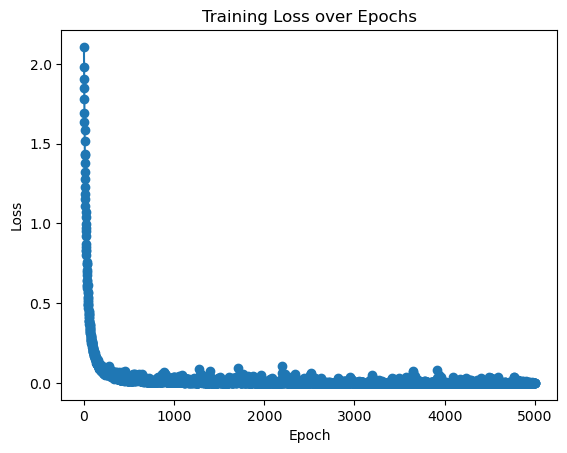

Final training loss: 0.0002745153588019529
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


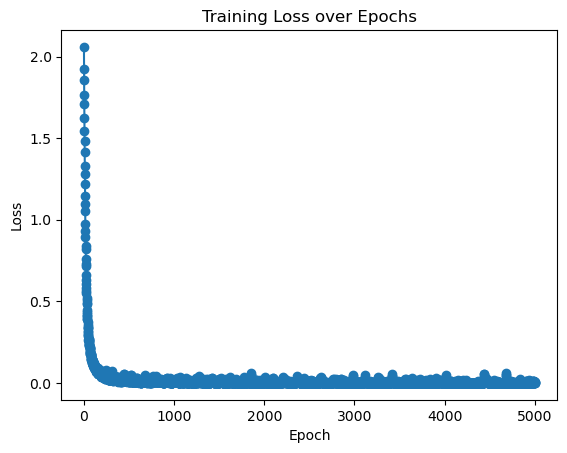

Final training loss: 0.0019553344831556864
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


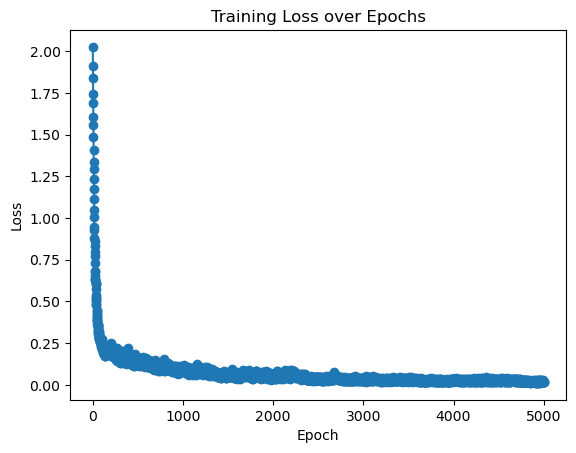

Final training loss: 0.016193165097087913
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


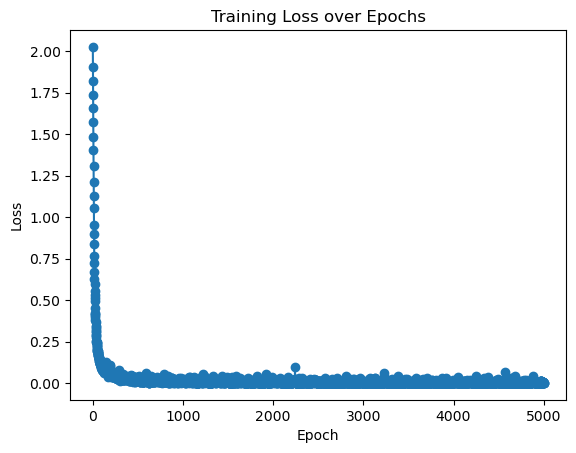

Final training loss: 0.0009356319818547682
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


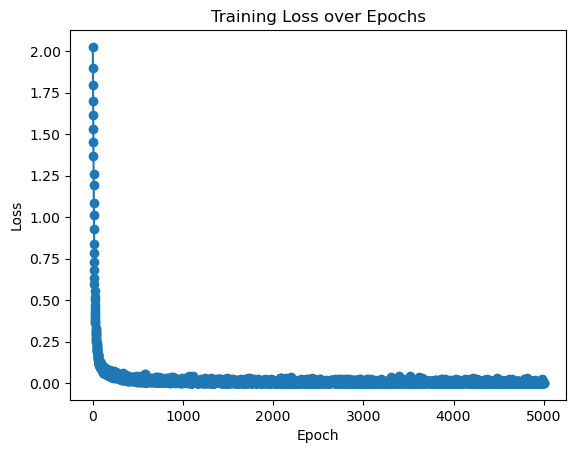

Final training loss: 0.0014490106226454288
[TorchWrapper] Using device: mps


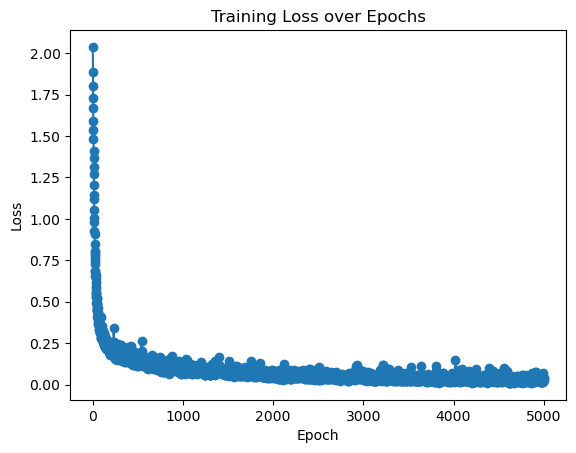

Final training loss: 0.0305309873110602
{'home_goals_train_accuracy': 1.0, 'home_goals_train_precision': 1.0, 'home_goals_valid_accuracy': 0.27076023391812865, 'home_goals_valid_precision': 0.1617022225816085, 'home_goals_test_accuracy': 0.2719298245614035, 'home_goals_test_precision': 0.1509139427061114, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 1.0, 'home_goals_train_gt_0_accuracy_std': 0.0, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 1.0, 'home_goals_train_gt_1_accuracy_std': 0.0, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 1.0, 'home_goals_train_gt_2_accuracy_std': 0.0, 'home_goals_train_gt_2_precision': 1.0, 'home_goals_train_gt_2_precision_std': 0.0, 'home_goals_train_gt_3_ac

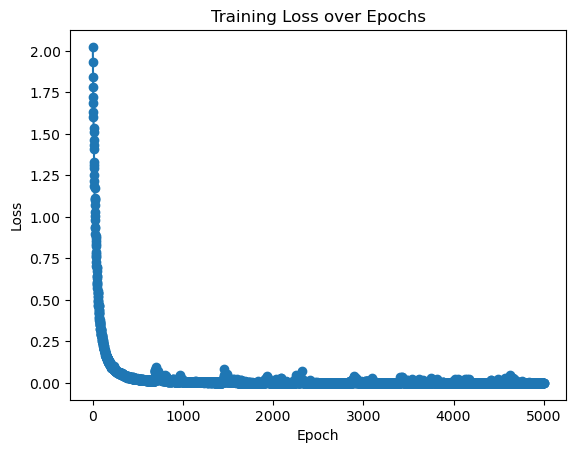

Final training loss: 0.00025756529679423883
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


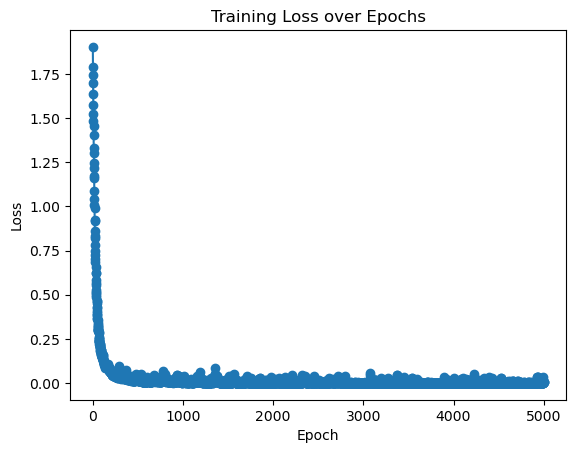

Final training loss: 0.0064358102125034
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


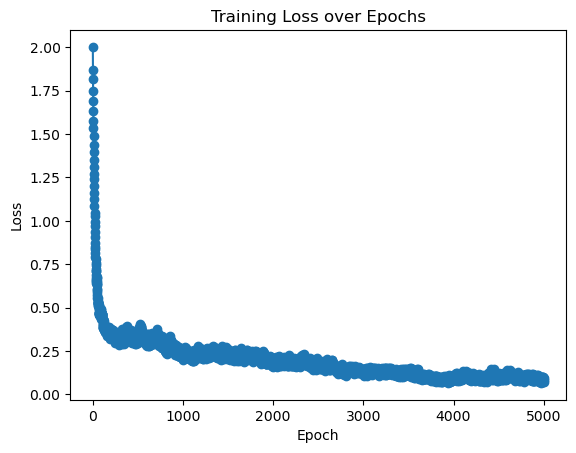

Final training loss: 0.09409593373943723
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


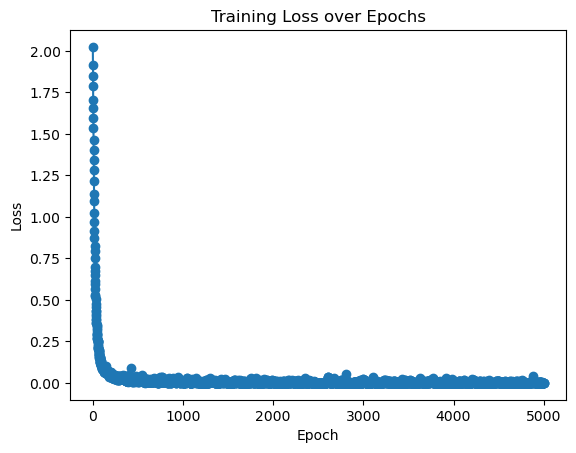

Final training loss: 0.00044308833232250237
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


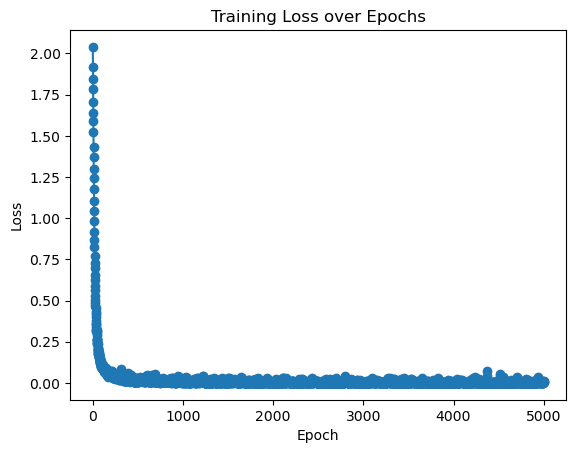

Final training loss: 0.004956222045758183
[TorchWrapper] Using device: mps


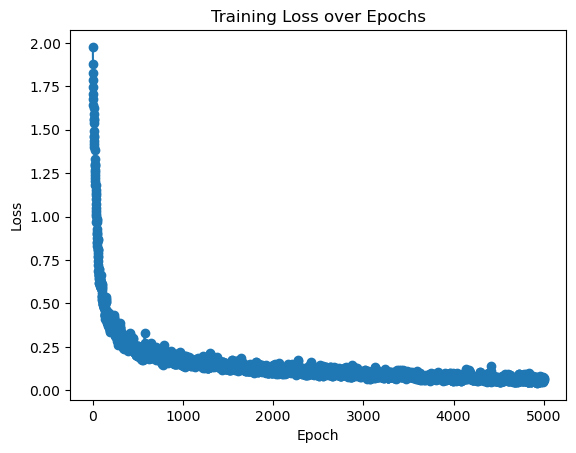

Final training loss: 0.058482340553350616
{'home_goals_train_accuracy': 0.9994152046783625, 'home_goals_train_precision': 0.9990578081452846, 'home_goals_valid_accuracy': 0.26959064327485377, 'home_goals_valid_precision': 0.16314202546090942, 'home_goals_test_accuracy': 0.2543859649122807, 'home_goals_test_precision': 0.16223800951523723, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 1.0, 'home_goals_train_gt_0_accuracy_std': 0.0, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 0.9997076023391813, 'home_goals_train_gt_1_accuracy_std': 0.0005847953216374435, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 0.9997076023391813, 'home_goals_train_gt_2_accuracy_std': 0.0005847953216374435, 'home_goa

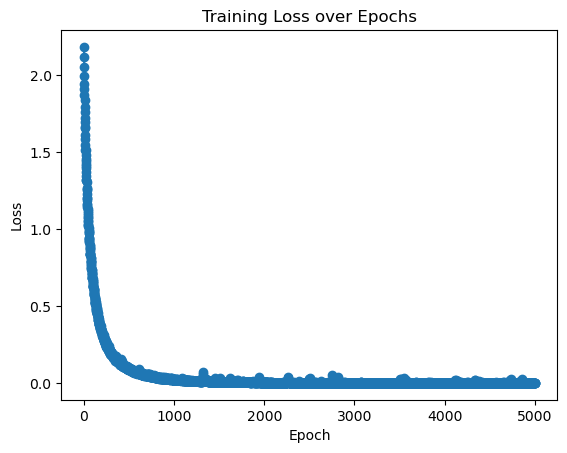

Final training loss: 0.0006107792431183639
Training fold 2/5 with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


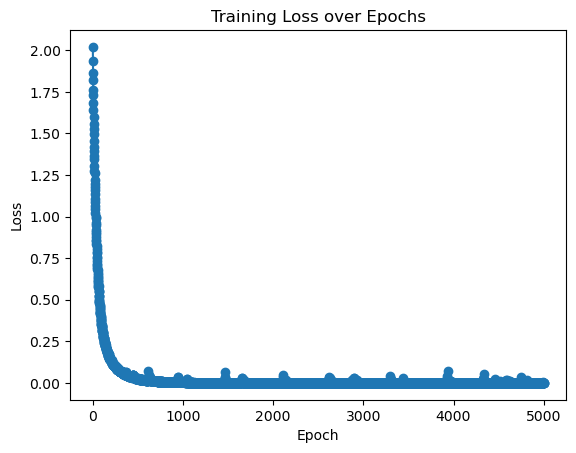

Final training loss: 0.00026083314772259596
Training fold 3/5 with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


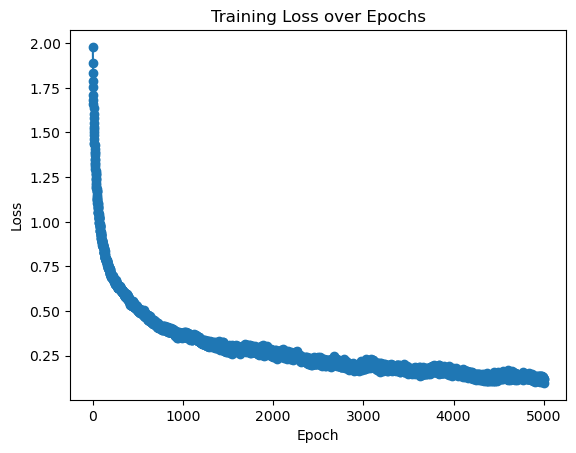

Final training loss: 0.11885061598660653
Training fold 4/5 with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


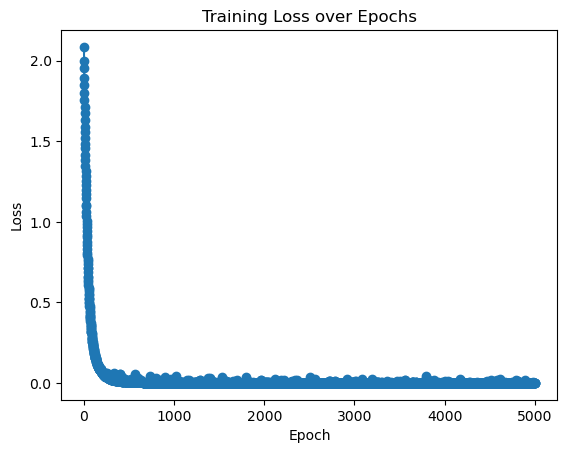

Final training loss: 0.0008774651473181115
Training fold 5/5 with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
[TorchWrapper] Using device: mps


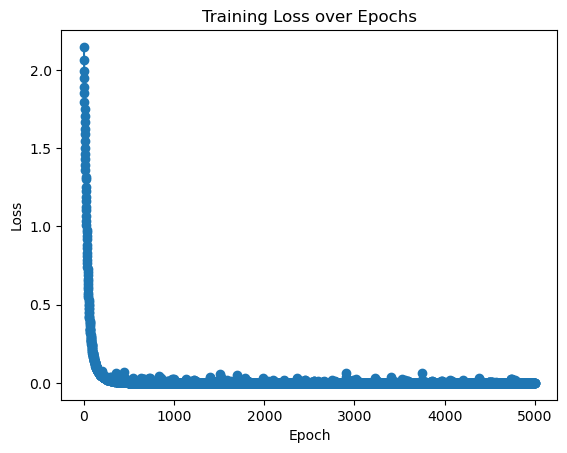

Final training loss: 0.00024077939686545155
[TorchWrapper] Using device: mps


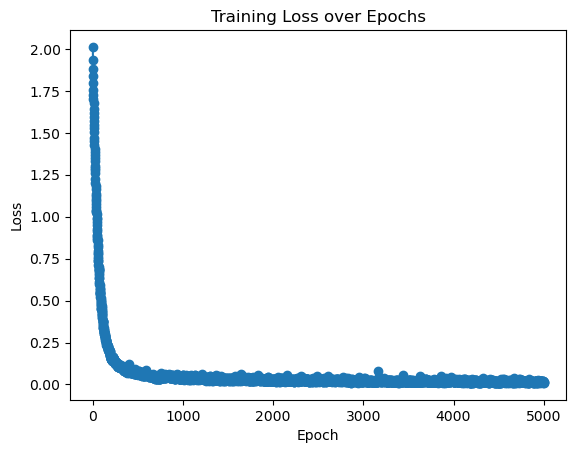

Final training loss: 0.015422113479403724
{'away_goals_train_accuracy': 0.998635477582846, 'away_goals_train_precision': 0.9948354890201696, 'away_goals_valid_accuracy': 0.28362573099415206, 'away_goals_valid_precision': 0.12453431532481762, 'away_goals_test_accuracy': 0.21052631578947367, 'away_goals_test_precision': 0.14206172899781921, 'away_goals_train_lte_0_accuracy': 0.9994152046783625, 'away_goals_train_lte_0_accuracy_std': 0.0011695906432748425, 'away_goals_train_lte_0_precision': 0.9988095238095237, 'away_goals_train_lte_0_precision_std': 0.002380952380952372, 'away_goals_train_gt_0_accuracy': 0.9994152046783625, 'away_goals_train_gt_0_accuracy_std': 0.0011695906432748425, 'away_goals_train_gt_0_precision': 0.9997101449275363, 'away_goals_train_gt_0_precision_std': 0.0005797101449275477, 'away_goals_train_gt_1_accuracy': 0.9994152046783625, 'away_goals_train_gt_1_accuracy_std': 0.0011695906432748425, 'away_goals_train_gt_1_precision': 0.999425287356322, 'away_goals_train_gt_1_

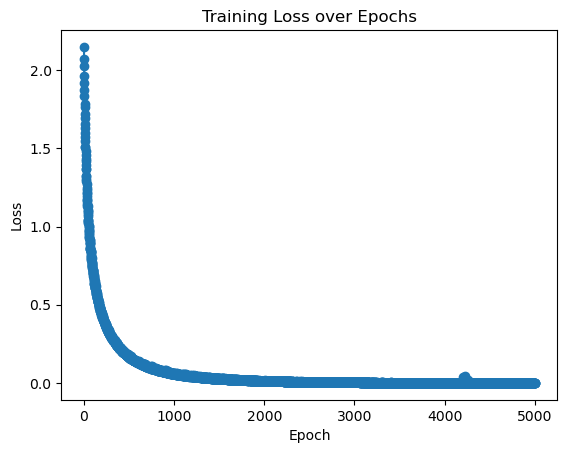

Final training loss: 0.0004320133484938122
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


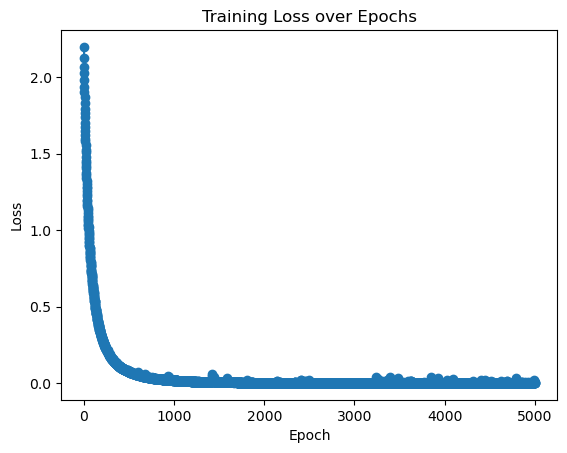

Final training loss: 0.000474132831638668
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


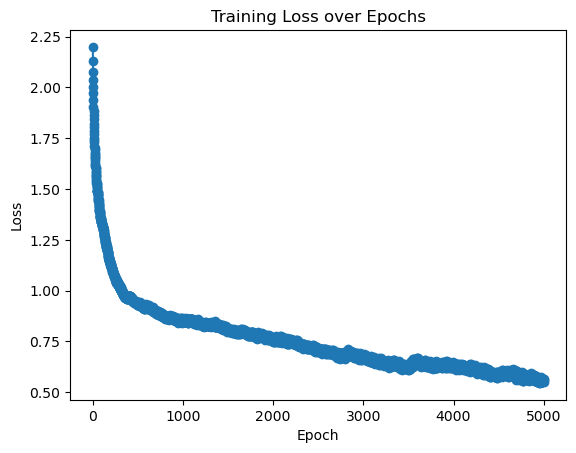

Final training loss: 0.549854380345484
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


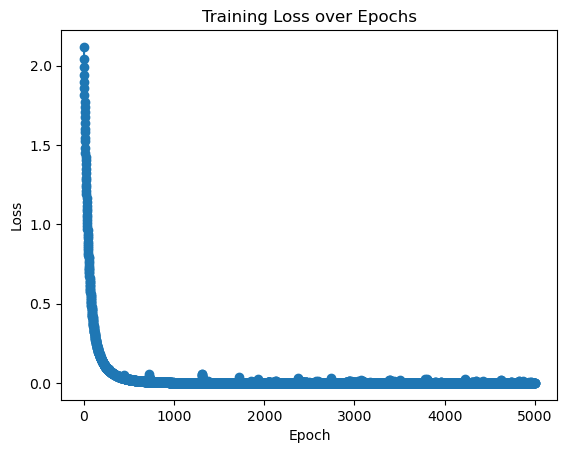

Final training loss: 0.00023115382093067516
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 5000}
[TorchWrapper] Using device: mps


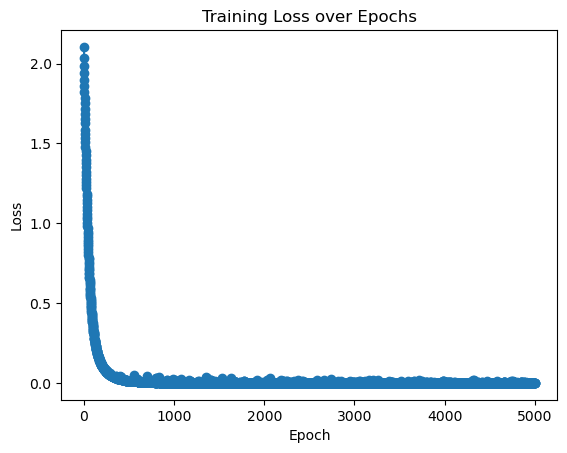

Final training loss: 0.0002221659390590758
[TorchWrapper] Using device: mps


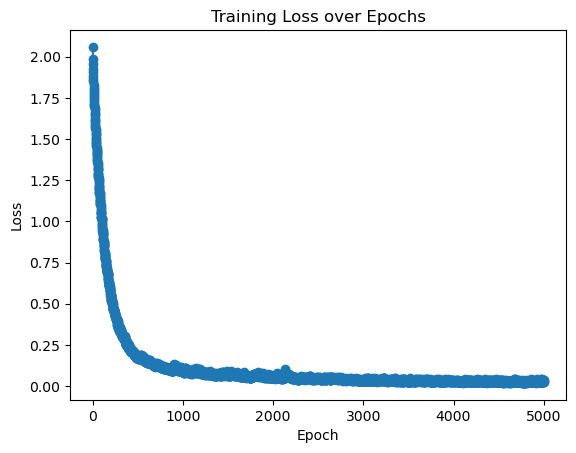

Final training loss: 0.03627276792396114
{'away_goals_train_accuracy': 0.9647173489278753, 'away_goals_train_precision': 0.9316486962358157, 'away_goals_valid_accuracy': 0.2964912280701754, 'away_goals_valid_precision': 0.13359808684989966, 'away_goals_test_accuracy': 0.21929824561403508, 'away_goals_test_precision': 0.1347697377193944, 'away_goals_train_lte_0_accuracy': 0.9818713450292398, 'away_goals_train_lte_0_accuracy_std': 0.036257309941520474, 'away_goals_train_lte_0_precision': 0.9650537634408602, 'away_goals_train_lte_0_precision_std': 0.06989247311827955, 'away_goals_train_gt_0_accuracy': 0.9818713450292398, 'away_goals_train_gt_0_accuracy_std': 0.036257309941520474, 'away_goals_train_gt_0_precision': 0.9914373088685015, 'away_goals_train_gt_0_precision_std': 0.017125382262996956, 'away_goals_train_gt_1_accuracy': 0.9777777777777779, 'away_goals_train_gt_1_accuracy_std': 0.04444444444444447, 'away_goals_train_gt_1_precision': 0.9775577557755776, 'away_goals_train_gt_1_precisi

KeyboardInterrupt: 

In [ ]:

run_multiclass_distribution_experiment(
    feature_df=feature_df,
    target_df=target_df,
    target_ranges=TRAINGING_CONFIG['target_ranges'],
    model_wrapper_class=lambda **params: TorchWrapper(
        model_class=MLPWithDropoutBN,
        model_params={k.replace('model_params.', ''): v for k, v in params.items() if k.startswith('model_params.')},
        learning_rate=params.get('learning_rate', 0.001),
        batch_size=params.get('batch_size', 64),
        epochs=params.get('epochs', 20)
    ),
    model_param_grid=param_grid,
    test_size=TRAINGING_CONFIG['test_size'],
    k=5,
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    uri=f'{REPO_PATH}/mlflow',
    model_name='MLPwithDropoutBN',
    key_columns=TRAINGING_CONFIG['key_columns'],
)

/Users/tianqihuang/Documents/GitHub/betbot/src/model/experiment_utils.py:126: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


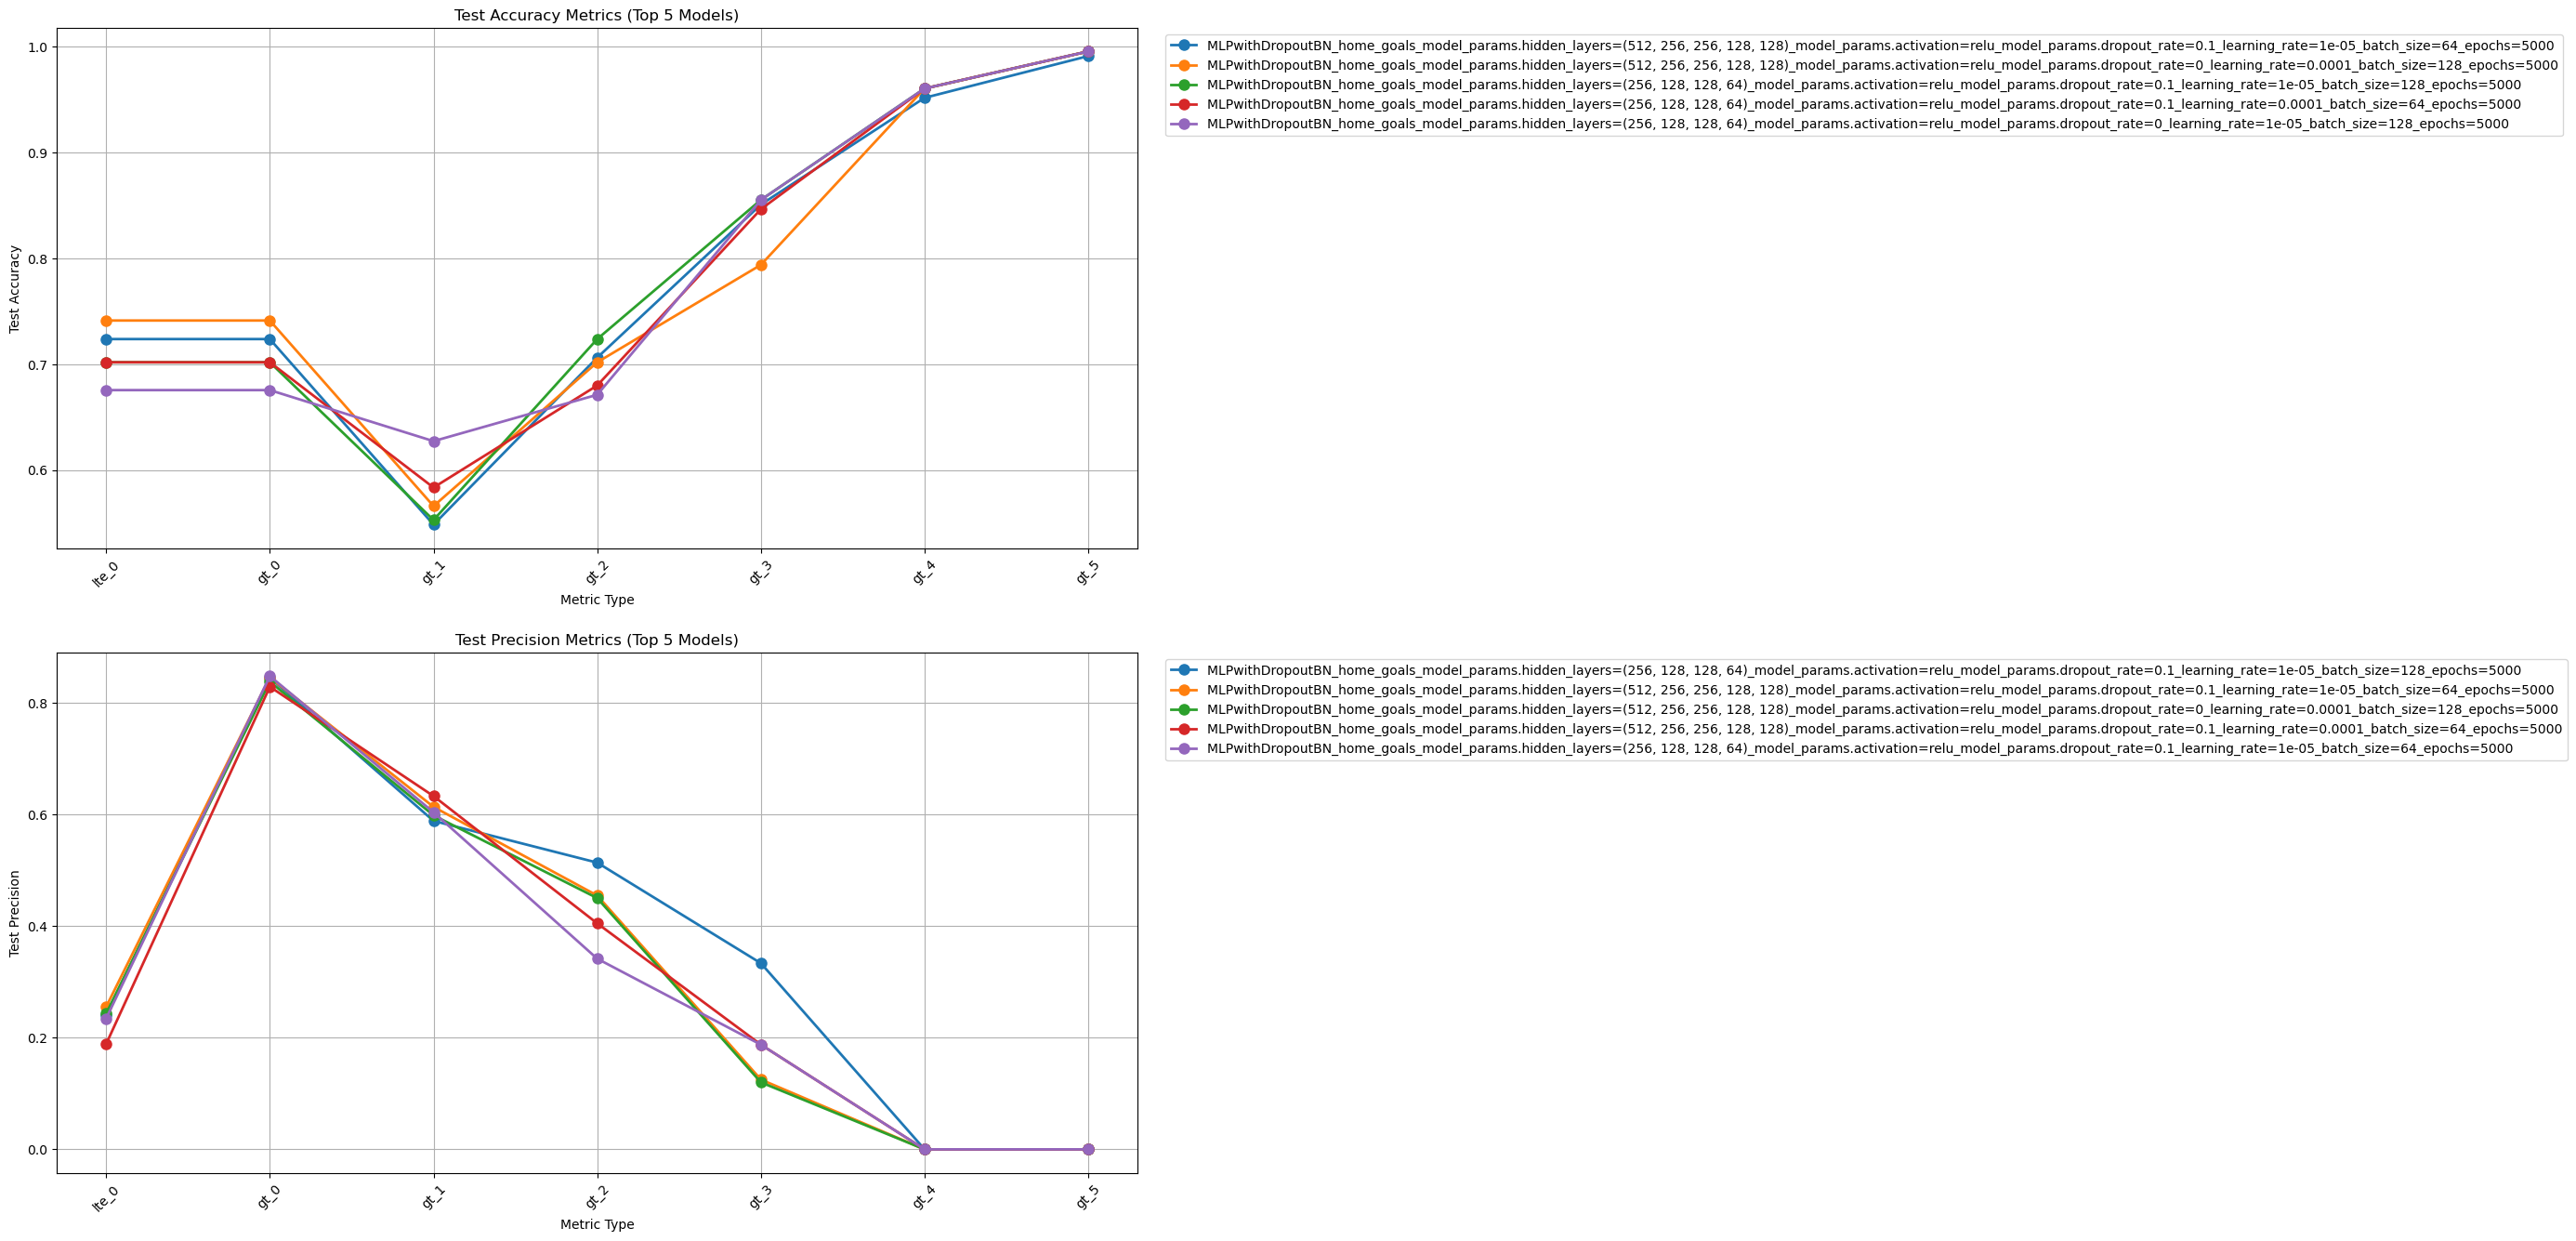

In [ ]:
plot_metrics_for_target_and_model(
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    target_col="home_goals",
    model_name="MLPwithDropoutBN",
    tracking_uri=f"{REPO_PATH}/mlflow"
)

In [ ]:
plot_run_metrics_by_split(experiment_name=TRAINGING_CONFIG['experiment_name'],
                         run_name="MLPwithDropoutBN_away_goals_{'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}",
                         target_col="home_goals",
                         tracking_uri=f"{REPO_PATH}/mlflow")

MlflowException: Invalid clause(s) in filter string: 'tags.mlflow.runName = 'MLPwithDropoutBN_away_goals_{'model_params.hidden_layers', '': (512, 256, 256, 128, 128), '', 'model_params.activation', '': '', 'relu', '', '', 'model_params.dropout_rate', '': 0, '', 'learning_rate', '': 1e-05, '', 'batch_size', '': 64, '', 'epochs', '': 5000}''

In [ ]:
plot_run_metrics_side_by_side(experiment_name=TRAINGING_CONFIG['experiment_name'],
                              model_name="MLPwithDropoutBN",
                              model_param={'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.00001, 'batch_size': 64, 'epochs': 5000},
                              tracking_uri=f"{REPO_PATH}/mlflow",
                              metric_type="precision")

Searching for runs with filter: params.model_name = 'MLPwithDropoutBN' and params.model_params.hidden_layers: '(512, 256, 256, 128, 128)' and params.model_params.activation: 'relu' and params.model_params.dropout_rate: '0' and params.learning_rate: '1e-05' and params.batch_size: '64' and params.epochs: '5000'


MlflowException: Invalid clause(s) in filter string: 'params.model_params.hidden_layers', ':', ''(512, 256, 256, 128, 128)'', 'params.model_params.activation', ':', ''relu'', 'params.model_params.dropout_rate', ':', ''0'', 'params.learning_rate', ':', ''1e-05'', 'params.batch_size', ':', ''64'', 'params.epochs', ':', ''5000''